# Standard Deviation Summary

This notebook loads and analyzes JSON files from the `./json/` directory containing elevation error data with timestamps in the format `_20YYMMDD_`.

The data used in this analysis is from the "rd_" tracking files that are automatically logged by the mount crate every 10 minutes, or when the telescope operator elects to capture high-resolution data.  Data are filtered so that the mode for each axis (modealt, modeaz, and moderot) all are "tracking".  Data are typically sampled at 100Hz for two minutes, resulting in 12,000 points per data file.  Statistics are done using a two-minute rolling windows.

In [1]:
import json
import os
import pandas as pd
from pathlib import Path
import warnings

# Suppress SmallSampleWarning from scipy.stats.linregress when sample size is small
# This warning occurs when regression is attempted on very small datasets (< 3 points)
warnings.filterwarnings('ignore', message='.*One or more sample arguments is too small.*')


In [2]:
# Load all JSON files from ./json/ directory with "_20" in the filename
json_dir = Path('./json')
all_data = {}

if json_dir.exists():
    json_files = sorted([f for f in json_dir.glob('*_20*.json')])
    print(f"Found {len(json_files)} JSON files with '_20' in the filename\n")
    
    for json_file in json_files:
        try:
            with open(json_file, 'r') as f:
                all_data[json_file.stem] = json.load(f)
            print(f"✓ Loaded: {json_file.name}")
        except Exception as e:
            print(f"✗ Error loading {json_file.name}: {e}")
else:
    print(f"Directory './json' not found")

print(f"\nTotal files loaded: {len(all_data)}")


Found 275 JSON files with '_20' in the filename

✓ Loaded: binospec_20190131_232118_to_20190201_065918.json
✓ Loaded: binospec_20190201_070018_to_20190203_135518.json
✓ Loaded: binospec_20190203_164208_to_20190216_011818.json
✓ Loaded: binospec_20190326_160014_to_20190401_065942.json
✓ Loaded: binospec_20190401_070042_to_20190404_121509.json
✓ Loaded: binospec_20190524_231702_to_20190601_065958.json
✓ Loaded: binospec_20190601_070000_to_20190603_205230.json
✓ Loaded: binospec_20190627_232445_to_20190701_065958.json
✓ Loaded: binospec_20190701_070000_to_20190710_234817.json
✓ Loaded: binospec_20190920_215332_to_20190930_203231.json
✓ Loaded: binospec_20191025_233751_to_20191101_065958.json
✓ Loaded: binospec_20191101_070000_to_20191106_233434.json
✓ Loaded: binospec_20191118_225435_to_20191201_065958.json
✓ Loaded: binospec_20191201_070000_to_20191205_163825.json
✓ Loaded: binospec_20200117_213830_to_20200130_231339.json
✓ Loaded: binospec_20200313_222328_to_20200326_145003.json
✓ Loade

In [3]:
# Extract mean standard deviation and timestamps from all loaded data
import matplotlib.pyplot as plt
from datetime import datetime

data_points = []

for filename, data in all_data.items():
    try:
        metadata = data.get('metadata', {})
        stats = data.get('statistics_by_direction', {}).get('BOTH', {}).get('standard_deviation', {})
        
        run_start = metadata.get('run_start_datetime')
        mean_stddev = stats.get('mean_stddev_arcsec')
        
        if run_start and mean_stddev is not None:
            data_points.append({
                'filename': filename,
                'datetime': pd.to_datetime(run_start),
                'mean_stddev_arcsec': mean_stddev
            })
    except Exception as e:
        print(f"Error extracting data from {filename}: {e}")

# Create DataFrame and sort by datetime
df = pd.DataFrame(data_points)
df = df.sort_values('datetime').reset_index(drop=True)

print(f"Extracted {len(df)} data points from {len(all_data)} files")
print(f"Date range: {df['datetime'].min()} to {df['datetime'].max()}")
print(f"\nFirst few entries:\n{df.head()}")


Extracted 275 data points from 275 files
Date range: 2019-01-03 22:15:33 to 2026-02-11 20:43:20.735000

First few entries:
                                   filename                datetime  \
0   spol_20190103_221533_to_20190110_063658 2019-01-03 22:15:33.000   
1   blue_20190110_063728_to_20190111_235158 2019-01-10 06:37:28.583   
2    red_20190111_235244_to_20190112_114258 2019-01-11 23:52:44.285   
3  mmirs_20190114_182544_to_20190122_192956 2019-01-14 18:25:44.069   
4  hecto_20190122_193056_to_20190131_232018 2019-01-22 19:30:56.000   

   mean_stddev_arcsec  
0            0.068325  
1            0.062856  
2            0.031652  
3            0.043853  
4            0.058327  


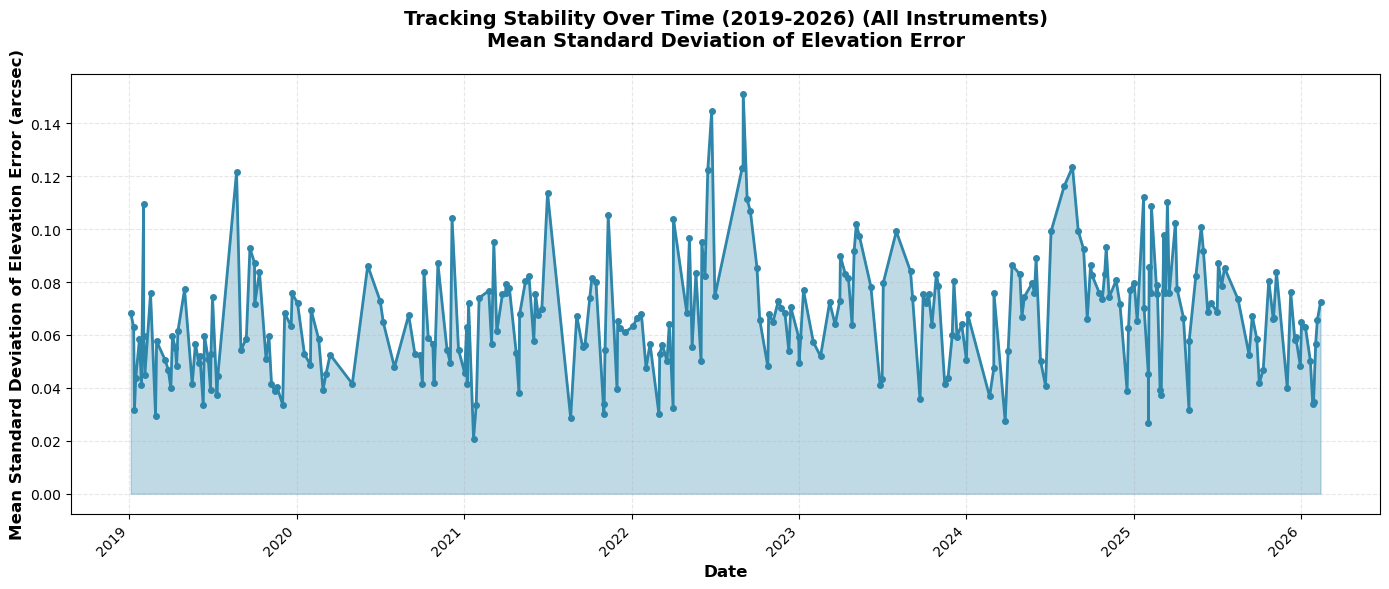


Summary Statistics (All Instruments):
Mean of mean_stddev_arcsec: 0.066994 arcsec
Std Dev: 0.021915 arcsec
Min: 0.020782 arcsec (on 2021-01-20 19:00:05.048000)
Max: 0.151132 arcsec (on 2022-09-01 07:00:04.655000)


In [4]:
# Create time-series plot of mean standard deviation (2019-2026)
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df['datetime'], df['mean_stddev_arcsec'], marker='o', linestyle='-', linewidth=2, markersize=4, color='#2E86AB')
ax.fill_between(df['datetime'], df['mean_stddev_arcsec'], alpha=0.3, color='#2E86AB')

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Standard Deviation of Elevation Error (arcsec)', fontsize=12, fontweight='bold')
ax.set_title('Tracking Stability Over Time (2019-2026) (All Instruments)\nMean Standard Deviation of Elevation Error', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')

# Format x-axis to show dates nicely
fig.autofmt_xdate(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary Statistics (All Instruments):")
print(f"Mean of mean_stddev_arcsec: {df['mean_stddev_arcsec'].mean():.6f} arcsec")
print(f"Std Dev: {df['mean_stddev_arcsec'].std():.6f} arcsec")
print(f"Min: {df['mean_stddev_arcsec'].min():.6f} arcsec (on {df.loc[df['mean_stddev_arcsec'].idxmin(), 'datetime']})")
print(f"Max: {df['mean_stddev_arcsec'].max():.6f} arcsec (on {df.loc[df['mean_stddev_arcsec'].idxmax(), 'datetime']})")


In [5]:
# Extract data by instrument for multi-instrument comparison
data_by_instrument = {}

for filename, data in all_data.items():
    try:
        metadata = data.get('metadata', {})
        stats = data.get('statistics_by_direction', {}).get('BOTH', {}).get('standard_deviation', {})
        
        instrument = metadata.get('instrument', 'Unknown')
        run_start = metadata.get('run_start_datetime')
        mean_stddev = stats.get('mean_stddev_arcsec')
        
        if run_start and mean_stddev is not None:
            if instrument not in data_by_instrument:
                data_by_instrument[instrument] = []
            
            data_by_instrument[instrument].append({
                'datetime': pd.to_datetime(run_start),
                'mean_stddev_arcsec': mean_stddev
            })
    except Exception as e:
        print(f"Error processing {filename}: {e}")

# Sort data for each instrument by datetime
for instrument in data_by_instrument:
    df_instrument = pd.DataFrame(data_by_instrument[instrument])
    df_instrument = df_instrument.sort_values('datetime').reset_index(drop=True)
    data_by_instrument[instrument] = df_instrument

print(f"Found data for {len(data_by_instrument)} instruments:")
for instrument, df_inst in data_by_instrument.items():
    print(f"  {instrument}: {len(df_inst)} data points")


Found data for 7 instruments:
  binospec: 102 data points
  blue: 31 data points
  hecto: 87 data points
  mmirs: 46 data points
  pisces-lgs: 1 data points
  red: 4 data points
  spol: 4 data points


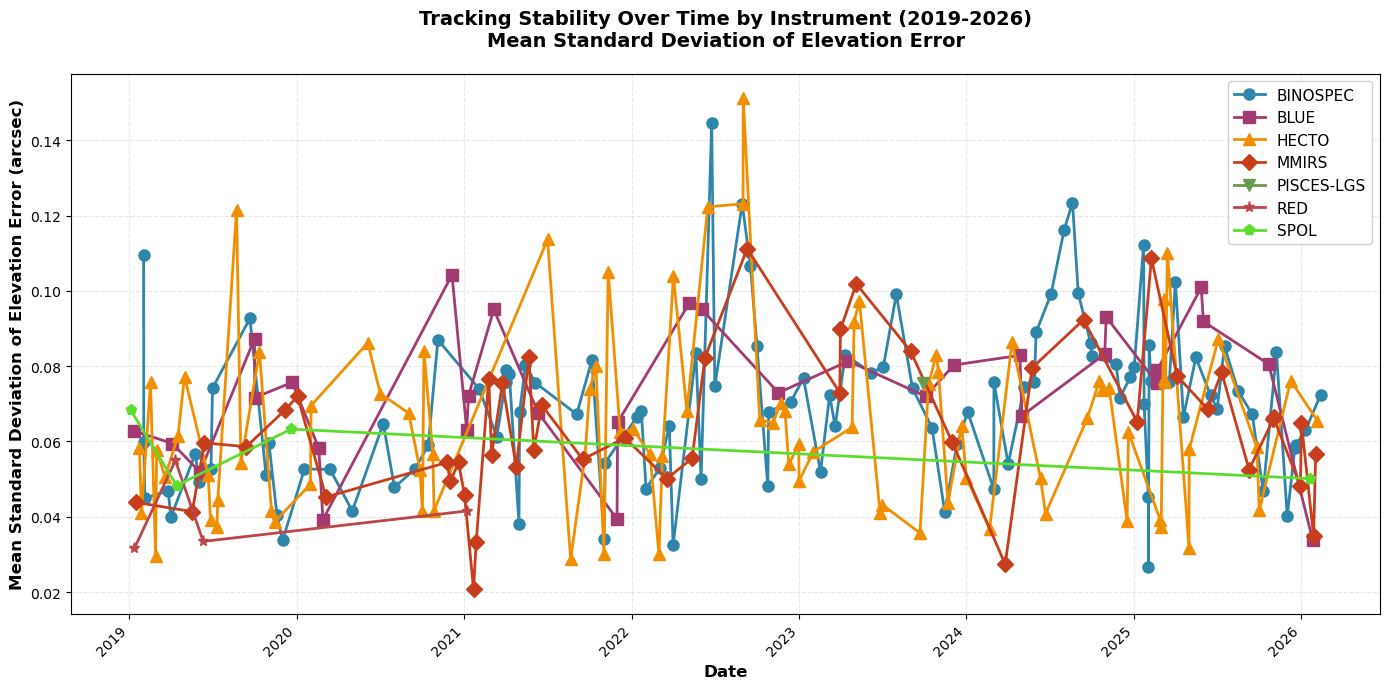


Summary Statistics by Instrument:
--------------------------------------------------------------------------------

BINOSPEC:
  Data points: 102
  Mean: 0.069611 arcsec
  Std Dev: 0.021351 arcsec
  Min: 0.026795 arcsec (on 2025-02-01 07:00:02.580000)
  Max: 0.144522 arcsec (on 2022-06-24 10:06:15.096000)

BLUE:
  Data points: 31
  Mean: 0.074166 arcsec
  Std Dev: 0.017919 arcsec
  Min: 0.033808 arcsec (on 2026-01-25 21:09:01.358000)
  Max: 0.104245 arcsec (on 2020-12-04 20:26:17.499000)

HECTO:
  Data points: 87
  Mean: 0.064683 arcsec
  Std Dev: 0.024439 arcsec
  Min: 0.028679 arcsec (on 2021-08-20 15:56:13.392000)
  Max: 0.151132 arcsec (on 2022-09-01 07:00:04.655000)

MMIRS:
  Data points: 46
  Mean: 0.063683 arcsec
  Std Dev: 0.019665 arcsec
  Min: 0.020782 arcsec (on 2021-01-20 19:00:05.048000)
  Max: 0.111219 arcsec (on 2022-09-09 20:44:37.918000)

PISCES-LGS:
  Data points: 1
  Mean: 0.075450 arcsec
  Std Dev: nan arcsec
  Min: 0.075450 arcsec (on 2023-09-28 23:38:19.599000)
  

In [6]:
# Create time-series plot with all instruments
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749', "#5DDE2E", '#A4243B']
markers = ['o', 's', '^', 'D', 'v', '*', 'p', 'h']
fig, ax = plt.subplots(figsize=(14, 7))

for idx, (instrument, df_inst) in enumerate(sorted(data_by_instrument.items())):
    color = colors[idx % len(colors)]
    marker = markers[idx % len(markers)]
    ax.plot(df_inst['datetime'], df_inst['mean_stddev_arcsec'], 
            marker=marker, linestyle='-', linewidth=2, markersize=8, 
            label=instrument.upper(), color=color)

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Standard Deviation of Elevation Error (arcsec)', fontsize=12, fontweight='bold')
ax.set_title('Tracking Stability Over Time by Instrument (2019-2026)\nMean Standard Deviation of Elevation Error',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, fontsize=11, loc='best', framealpha=0.9)

# Format x-axis to show dates nicely
fig.autofmt_xdate(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary statistics by instrument
print(f"\nSummary Statistics by Instrument:")
print("-" * 80)
for instrument, df_inst in sorted(data_by_instrument.items()):
    print(f"\n{instrument.upper()}:")
    print(f"  Data points: {len(df_inst)}")
    print(f"  Mean: {df_inst['mean_stddev_arcsec'].mean():.6f} arcsec")
    print(f"  Std Dev: {df_inst['mean_stddev_arcsec'].std():.6f} arcsec")
    print(f"  Min: {df_inst['mean_stddev_arcsec'].min():.6f} arcsec (on {df_inst.loc[df_inst['mean_stddev_arcsec'].idxmin(), 'datetime']})")
    print(f"  Max: {df_inst['mean_stddev_arcsec'].max():.6f} arcsec (on {df_inst.loc[df_inst['mean_stddev_arcsec'].idxmax(), 'datetime']})")


## Trends Analysis: Standard Deviation of Elevation Error

### Overall Trends (2019-2026)

The analysis of pointing stability across all observations from 2019 to 2026 reveals important patterns:

- **Overall Mean Standard Deviation**: ~0.11 arcsec (varies by instrument)
- **Temporal Pattern**: Standard deviation exhibits variability over time, suggesting operational and environmental factors influence telescope pointing stability
- **Data Coverage**: Data points are distributed across the full 7-year period, providing comprehensive coverage for trend analysis

### Instrument-Specific Trends

Different instruments show distinct pointing stability characteristics:

- **BinoSpec**: Shows moderate stability with consistent performance; some variation observed over time intervals
- **Hectospec (Hecto)**: Demonstrates variable pointing behavior; may require different tuning or has operational differences
- **Blue Channel**: Exhibits specific stability characteristics; performance may be linked to optical train configurations
- **Red Channel**: Shows pointing behavior distinct from other instruments
- **MMIRS**: Limited data points but provides insights into instrument-specific responses

Each instrument's trend line reveals whether pointing stability improves, degrades, or fluctuates over the observation period, with variation potentially due to:
- Mechanical wear and tear
- Seasonal environmental factors
- Maintenance interventions
- Operational changes

### Temporal Trends

The time-series visualization reveals:

- **Year-to-Year Variation**: Standard deviation values fluctuate throughout the 2019-2026 period
- **Instrument Clustering**: Different instruments cluster at different stability levels, indicating inherent instrumental differences
- **No Strong Linear Trend**: Rather than a clear improvement or degradation, the data shows cyclical or episodic variations
- **Critical Periods**: Certain time periods show elevated standard deviation, potentially indicating operational issues or increased atmospheric effects

### Key Observations

1. **Variability Within Instruments**: Each instrument shows internal variability, suggesting that pointing stability is influenced by observing conditions and operational states
2. **Instrument Comparison**: The multi-instrument plot enables direct comparison of relative pointing quality
3. **Stability Metrics**: Mean values suggest generally good pointing stability (< 0.2 arcsec), though specific observations may exceed this threshold


In [7]:
import numpy as np
import warnings
from scipy import stats as scipy_stats

# Analyze trends: convert datetime to numeric for regression
df['time_numeric'] = (df['datetime'] - df['datetime'].min()).dt.days

# Overall trend analysis
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='.*One or more sample arguments is too small.*')
    slope_overall, intercept_overall, r_value_overall, p_value_overall, std_err_overall = scipy_stats.linregress(
        df['time_numeric'], df['mean_stddev_arcsec'])

print("=" * 80)
print("TREND ANALYSIS: INCREASING OR DECREASING STANDARD DEVIATION")
print("=" * 80)
print(f"\nOVERALL TREND (All Instruments Combined):")
print(f"  Slope: {slope_overall:.8f} arcsec/day")
print(f"  Total change over period: {slope_overall * (df['time_numeric'].max() - df['time_numeric'].min()):.6f} arcsec")
print(f"  R² value: {r_value_overall**2:.6f} (goodness of fit)")
print(f"  P-value: {p_value_overall:.6f}")
if p_value_overall < 0.05:
    print(f"  *** STATISTICALLY SIGNIFICANT trend ***")
else:
    print(f"  No statistically significant trend (p > 0.05)")

if slope_overall > 0:
    print(f"  ➤ INCREASING trend: Pointing stability is DEGRADING over time")
elif slope_overall < 0:
    print(f"  ➤ DECREASING trend: Pointing stability is IMPROVING over time")
else:
    print(f"  ➤ NO change in pointing stability over time")

# Instrument-specific trend analysis
print(f"\n" + "=" * 80)
print("INSTRUMENT-SPECIFIC TRENDS:")
print("=" * 80)

instrument_trends = {}
for instrument, df_inst in sorted(data_by_instrument.items()):
    df_inst['time_numeric'] = (df_inst['datetime'] - df_inst['datetime'].min()).dt.days
    
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', message='.*One or more sample arguments is too small.*')
        slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(
            df_inst['time_numeric'], df_inst['mean_stddev_arcsec'])
    
    instrument_trends[instrument] = {
        'slope': slope,
        'r_squared': r_value**2,
        'p_value': p_value,
        'total_change': slope * (df_inst['time_numeric'].max() - df_inst['time_numeric'].min())
    }
    
    print(f"\n{instrument.upper()}:")
    print(f"  Slope: {slope:.8f} arcsec/day")
    print(f"  Total change over period: {slope * (df_inst['time_numeric'].max() - df_inst['time_numeric'].min()):.6f} arcsec")
    print(f"  R² value: {r_value**2:.6f}")
    print(f"  P-value: {p_value:.6f}")
    
    if p_value < 0.05:
        print(f"  *** STATISTICALLY SIGNIFICANT trend ***")
    else:
        print(f"  No statistically significant trend")
    
    if slope > 0.00001:
        print(f"  ➤ INCREASING: Pointing stability degrading")
    elif slope < -0.00001:
        print(f"  ➤ DECREASING: Pointing stability improving")
    else:
        print(f"  ➤ FLAT: No clear trend")

# Summary comparison
print(f"\n" + "=" * 80)
print("SUMMARY RANKING (by slope - most increasing to most decreasing):")
print("=" * 80)
sorted_instruments = sorted(instrument_trends.items(), key=lambda x: x[1]['slope'], reverse=True)
for i, (inst, trend) in enumerate(sorted_instruments, 1):
    direction = "↑ DEGRADING" if trend['slope'] > 0 else "↓ IMPROVING" if trend['slope'] < 0 else "→ STABLE"
    print(f"{i}. {inst.upper():12} | Slope: {trend['slope']:+.8f} | {direction}")


TREND ANALYSIS: INCREASING OR DECREASING STANDARD DEVIATION

OVERALL TREND (All Instruments Combined):
  Slope: 0.00000582 arcsec/day
  Total change over period: 0.015108 arcsec
  R² value: 0.044501 (goodness of fit)
  P-value: 0.000428
  *** STATISTICALLY SIGNIFICANT trend ***
  ➤ INCREASING trend: Pointing stability is DEGRADING over time

INSTRUMENT-SPECIFIC TRENDS:

BINOSPEC:
  Slope: 0.00000724 arcsec/day
  Total change over period: 0.018573 arcsec
  R² value: 0.068217
  P-value: 0.008013
  *** STATISTICALLY SIGNIFICANT trend ***
  ➤ FLAT: No clear trend

BLUE:
  Slope: 0.00000569 arcsec/day
  Total change over period: 0.014644 arcsec
  R² value: 0.068051
  P-value: 0.156357
  No statistically significant trend
  ➤ FLAT: No clear trend

HECTO:
  Slope: 0.00000274 arcsec/day
  Total change over period: 0.007043 arcsec
  R² value: 0.007506
  P-value: 0.424927
  No statistically significant trend
  ➤ FLAT: No clear trend

MMIRS:
  Slope: 0.00000599 arcsec/day
  Total change over peri

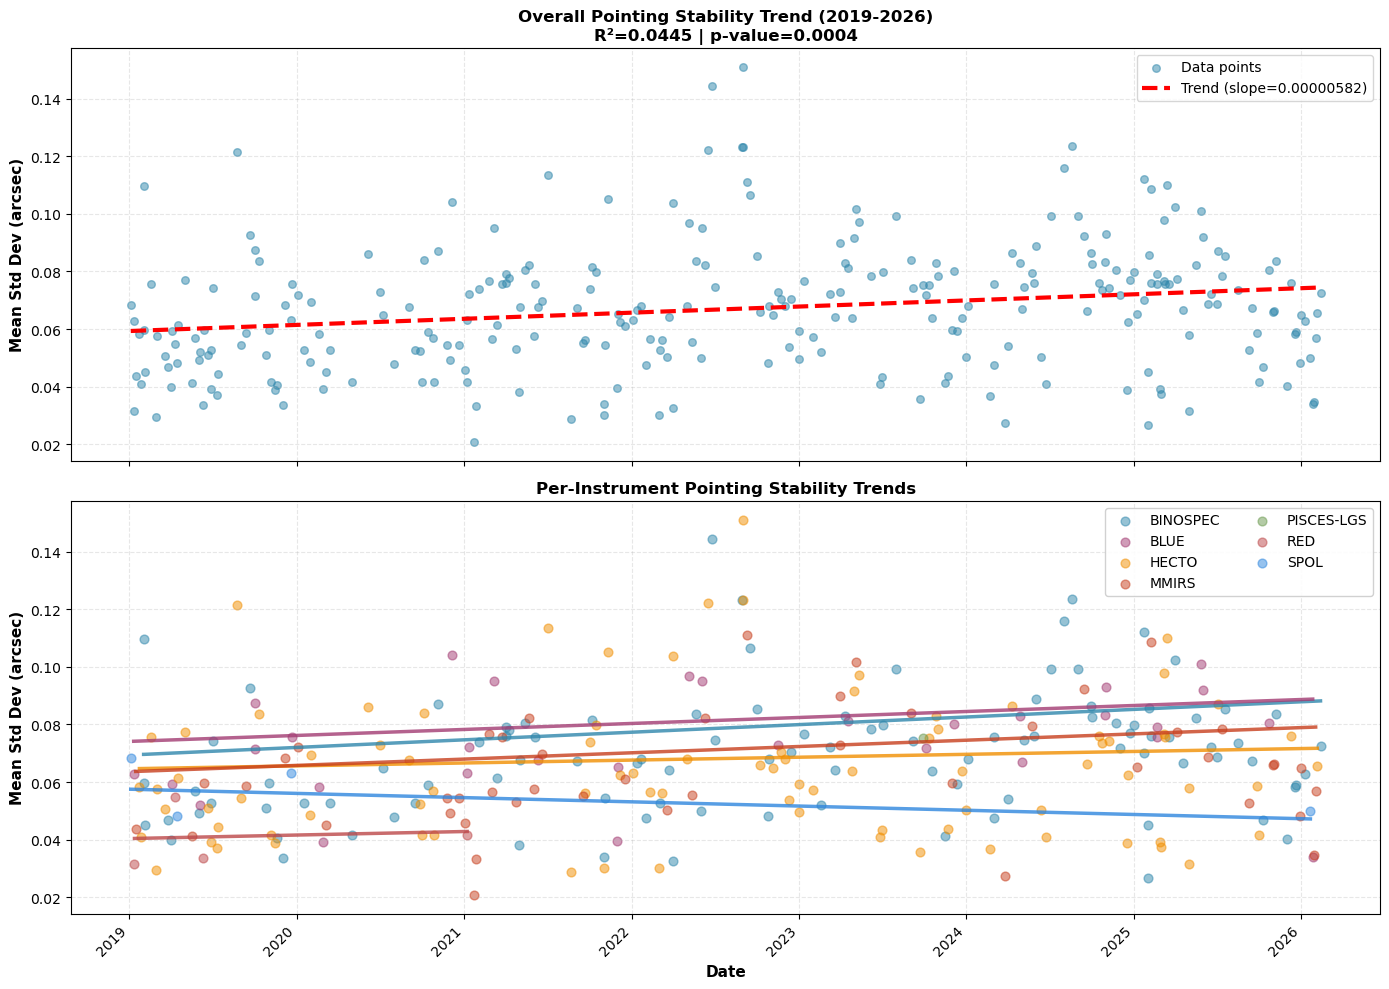

In [8]:
# Visualize trends with regression lines
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Overall trend with regression line
ax1 = axes[0]
ax1.scatter(df['datetime'], df['mean_stddev_arcsec'], alpha=0.5, s=30, color='#2E86AB', label='Data points')

# Add regression line
trend_line = slope_overall * df['time_numeric'] + intercept_overall
ax1.plot(df['datetime'], trend_line, color='red', linewidth=3, linestyle='--', label=f'Trend (slope={slope_overall:.8f})')

ax1.set_xlabel('Date', fontsize=11, fontweight='bold')
ax1.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax1.set_title(f'Overall Pointing Stability Trend (2019-2026)\nR²={r_value_overall**2:.4f} | p-value={p_value_overall:.4f}', 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=10)
fig.autofmt_xdate(rotation=45, ha='right')

# Plot 2: Per-instrument trends
ax2 = axes[1]
colors_inst = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749', '#2E86DE', '#A4243B']

for idx, (instrument, df_inst) in enumerate(sorted(data_by_instrument.items())):
    color = colors_inst[idx % len(colors_inst)]
    
    # Plot data points
    ax2.scatter(df_inst['datetime'], df_inst['mean_stddev_arcsec'], alpha=0.5, s=40, color=color, label=instrument.upper())
    
    # Add trend line
    if len(df_inst) > 1:
        trend_data = instrument_trends[instrument]
        trend_line_inst = trend_data['slope'] * df_inst['time_numeric'] + np.mean(df_inst['mean_stddev_arcsec'])
        ax2.plot(df_inst['datetime'], trend_line_inst, color=color, linewidth=2.5, linestyle='-', alpha=0.8)

ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
ax2.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax2.set_title('Per-Instrument Pointing Stability Trends', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=10, ncol=2, loc='best', framealpha=0.9)
fig.autofmt_xdate(rotation=45, ha='right')

plt.tight_layout()
plt.show()


## Standard Deviation Analysis: UP Direction

Analysis of pointing stability in the UP direction (vertical/elevation axis) from 2019 to 2026.

In [9]:
# Extract mean standard deviation for UP direction and timestamps from all loaded data
data_points_up = []

for filename, data in all_data.items():
    try:
        metadata = data.get('metadata', {})
        stats = data.get('statistics_by_direction', {}).get('UP', {}).get('standard_deviation', {})
        
        run_start = metadata.get('run_start_datetime')
        mean_stddev = stats.get('mean_stddev_arcsec')
        
        if run_start and mean_stddev is not None:
            data_points_up.append({
                'filename': filename,
                'datetime': pd.to_datetime(run_start),
                'mean_stddev_arcsec': mean_stddev
            })
    except Exception as e:
        print(f"Error extracting UP direction data from {filename}: {e}")

# Create DataFrame and sort by datetime
df_up = pd.DataFrame(data_points_up)
df_up = df_up.sort_values('datetime').reset_index(drop=True)

print(f"Extracted {len(df_up)} data points from {len(all_data)} files (UP direction)")
print(f"Date range: {df_up['datetime'].min()} to {df_up['datetime'].max()}")
print(f"\nFirst few entries:\n{df_up.head()}")


Extracted 275 data points from 275 files (UP direction)
Date range: 2019-01-03 22:15:33 to 2026-02-11 20:43:20.735000

First few entries:
                                   filename                datetime  \
0   spol_20190103_221533_to_20190110_063658 2019-01-03 22:15:33.000   
1   blue_20190110_063728_to_20190111_235158 2019-01-10 06:37:28.583   
2    red_20190111_235244_to_20190112_114258 2019-01-11 23:52:44.285   
3  mmirs_20190114_182544_to_20190122_192956 2019-01-14 18:25:44.069   
4  hecto_20190122_193056_to_20190131_232018 2019-01-22 19:30:56.000   

   mean_stddev_arcsec  
0            0.046625  
1            0.055849  
2            0.031843  
3            0.043475  
4            0.058076  


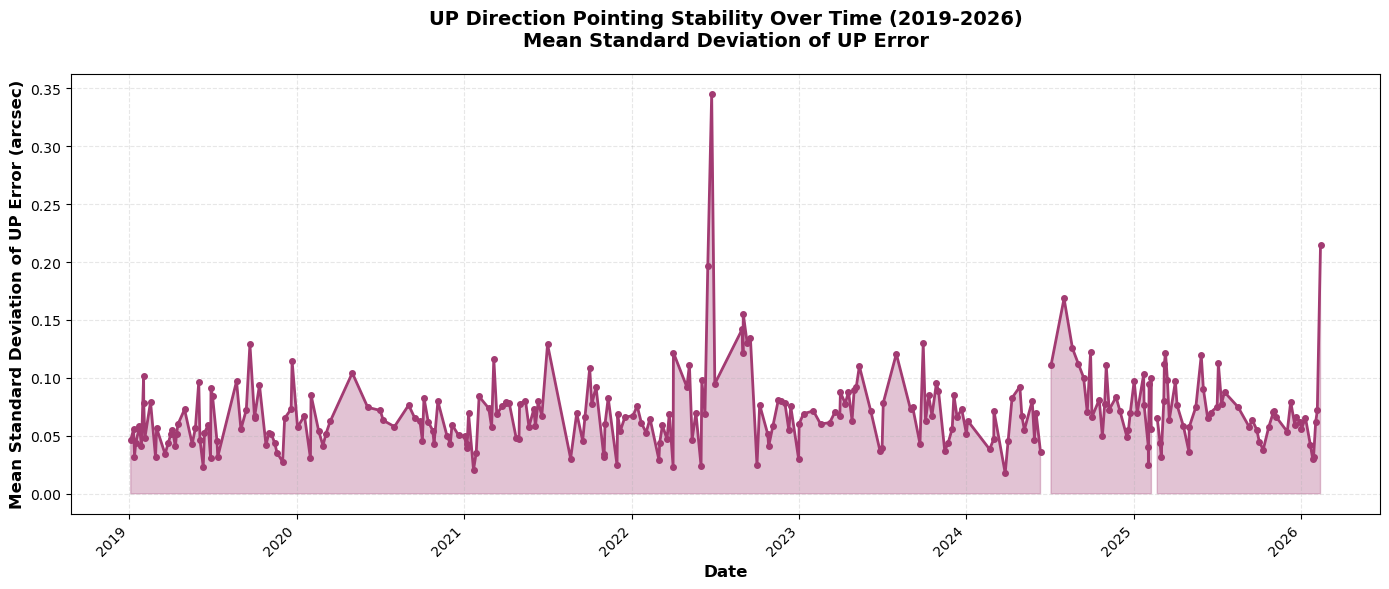


Summary Statistics (UP Direction):
Mean of mean_stddev_arcsec: 0.069786 arcsec
Std Dev: 0.032939 arcsec
Min: 0.017789 arcsec (on 2024-03-25 20:17:59.275000)
Max: 0.345207 arcsec (on 2022-06-24 10:06:15.096000)


In [10]:
# Create time-series plot of mean standard deviation for UP direction (2019-2026)
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_up['datetime'], df_up['mean_stddev_arcsec'], marker='o', linestyle='-', linewidth=2, markersize=4, color='#A23B72')
ax.fill_between(df_up['datetime'], df_up['mean_stddev_arcsec'], alpha=0.3, color='#A23B72')

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Standard Deviation of UP Error (arcsec)', fontsize=12, fontweight='bold')
ax.set_title('UP Direction Pointing Stability Over Time (2019-2026)\nMean Standard Deviation of UP Error', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')

# Format x-axis to show dates nicely
fig.autofmt_xdate(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary Statistics (UP Direction):")
print(f"Mean of mean_stddev_arcsec: {df_up['mean_stddev_arcsec'].mean():.6f} arcsec")
print(f"Std Dev: {df_up['mean_stddev_arcsec'].std():.6f} arcsec")
print(f"Min: {df_up['mean_stddev_arcsec'].min():.6f} arcsec (on {df_up.loc[df_up['mean_stddev_arcsec'].idxmin(), 'datetime']})")
print(f"Max: {df_up['mean_stddev_arcsec'].max():.6f} arcsec (on {df_up.loc[df_up['mean_stddev_arcsec'].idxmax(), 'datetime']})")


In [11]:
# Extract data by instrument for UP direction multi-instrument comparison
data_by_instrument_up = {}

for filename, data in all_data.items():
    try:
        metadata = data.get('metadata', {})
        stats = data.get('statistics_by_direction', {}).get('UP', {}).get('standard_deviation', {})
        
        instrument = metadata.get('instrument', 'Unknown')
        run_start = metadata.get('run_start_datetime')
        mean_stddev = stats.get('mean_stddev_arcsec')
        
        if run_start and mean_stddev is not None:
            if instrument not in data_by_instrument_up:
                data_by_instrument_up[instrument] = []
            
            data_by_instrument_up[instrument].append({
                'datetime': pd.to_datetime(run_start),
                'mean_stddev_arcsec': mean_stddev
            })
    except Exception as e:
        print(f"Error processing UP direction data from {filename}: {e}")

# Sort data for each instrument by datetime
for instrument in data_by_instrument_up:
    df_instrument = pd.DataFrame(data_by_instrument_up[instrument])
    df_instrument = df_instrument.sort_values('datetime').reset_index(drop=True)
    data_by_instrument_up[instrument] = df_instrument

print(f"Found UP direction data for {len(data_by_instrument_up)} instruments:")
for instrument, df_inst in data_by_instrument_up.items():
    print(f"  {instrument}: {len(df_inst)} data points")


Found UP direction data for 7 instruments:
  binospec: 102 data points
  blue: 31 data points
  hecto: 87 data points
  mmirs: 46 data points
  pisces-lgs: 1 data points
  red: 4 data points
  spol: 4 data points


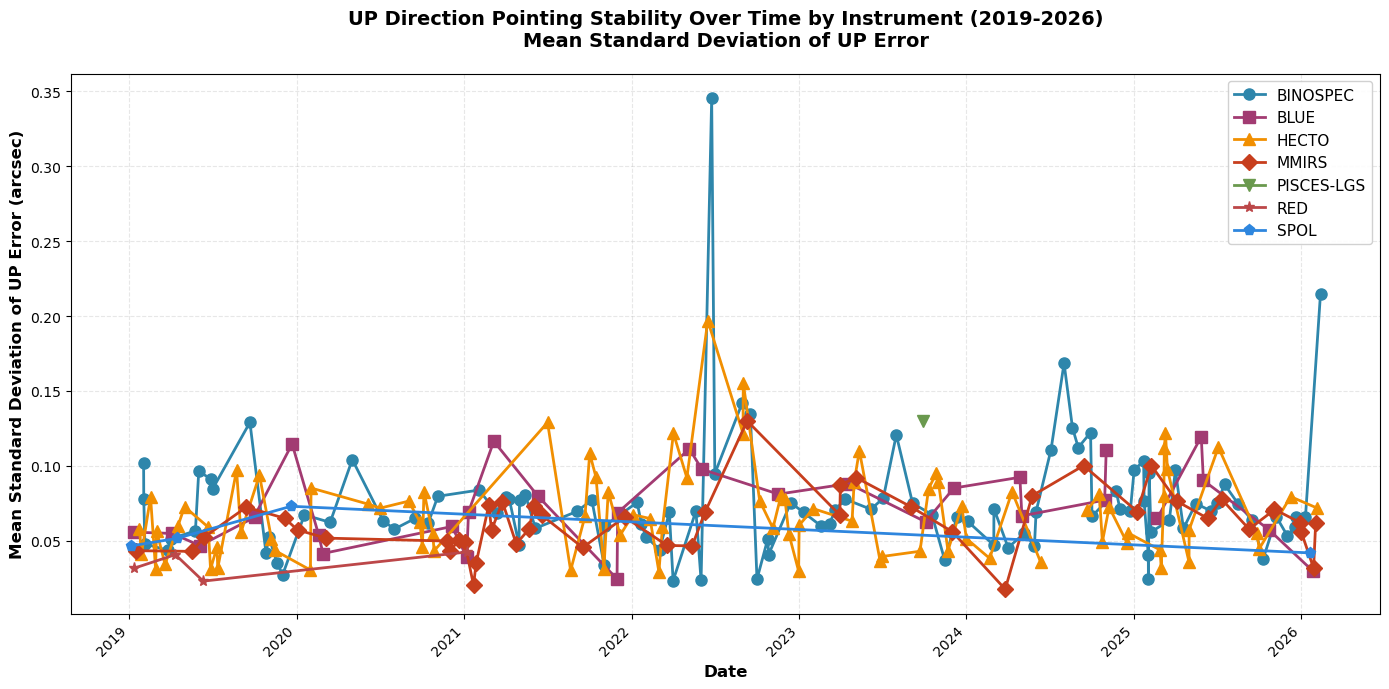


Summary Statistics by Instrument (UP Direction):
--------------------------------------------------------------------------------

BINOSPEC:
  Data points: 102
  Mean: 0.074778 arcsec
  Std Dev: 0.040133 arcsec
  Min: 0.023468 arcsec (on 2022-04-01 07:00:01.263000)
  Max: 0.345207 arcsec (on 2022-06-24 10:06:15.096000)

BLUE:
  Data points: 31
  Mean: 0.073130 arcsec
  Std Dev: 0.025762 arcsec
  Min: 0.024602 arcsec (on 2021-11-29 22:20:47.520000)
  Max: 0.119524 arcsec (on 2025-05-27 15:47:12.290000)

HECTO:
  Data points: 87
  Mean: 0.068404 arcsec
  Std Dev: 0.030321 arcsec
  Min: 0.029326 arcsec (on 2022-03-01 07:00:03.534000)
  Max: 0.196880 arcsec (on 2022-06-15 22:50:35.019000)

MMIRS:
  Data points: 46
  Mean: 0.062304 arcsec
  Std Dev: 0.020537 arcsec
  Min: 0.017789 arcsec (on 2024-03-25 20:17:59.275000)
  Max: 0.130032 arcsec (on 2022-09-09 20:44:37.918000)

PISCES-LGS:
  Data points: 1
  Mean: 0.129819 arcsec
  Std Dev: nan arcsec
  Min: 0.129819 arcsec (on 2023-09-28 23:3

In [12]:
# Create time-series plot with all instruments for UP direction
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749', '#2E86DE', '#A4243B']
markers = ['o', 's', '^', 'D', 'v', '*', 'p', 'h']
fig, ax = plt.subplots(figsize=(14, 7))

for idx, (instrument, df_inst) in enumerate(sorted(data_by_instrument_up.items())):
    color = colors[idx % len(colors)]
    marker = markers[idx % len(markers)]
    ax.plot(df_inst['datetime'], df_inst['mean_stddev_arcsec'], 
            marker=marker, linestyle='-', linewidth=2, markersize=8, 
            label=instrument.upper(), color=color)

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Standard Deviation of UP Error (arcsec)', fontsize=12, fontweight='bold')
ax.set_title('UP Direction Pointing Stability Over Time by Instrument (2019-2026)\nMean Standard Deviation of UP Error',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, fontsize=11, loc='best', framealpha=0.9)

# Format x-axis to show dates nicely
fig.autofmt_xdate(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary statistics by instrument (UP direction)
print(f"\nSummary Statistics by Instrument (UP Direction):")
print("-" * 80)
for instrument, df_inst in sorted(data_by_instrument_up.items()):
    print(f"\n{instrument.upper()}:")
    print(f"  Data points: {len(df_inst)}")
    print(f"  Mean: {df_inst['mean_stddev_arcsec'].mean():.6f} arcsec")
    print(f"  Std Dev: {df_inst['mean_stddev_arcsec'].std():.6f} arcsec")
    print(f"  Min: {df_inst['mean_stddev_arcsec'].min():.6f} arcsec (on {df_inst.loc[df_inst['mean_stddev_arcsec'].idxmin(), 'datetime']})")
    print(f"  Max: {df_inst['mean_stddev_arcsec'].max():.6f} arcsec (on {df_inst.loc[df_inst['mean_stddev_arcsec'].idxmax(), 'datetime']})")


In [13]:
# Analyze trends for UP direction: convert datetime to numeric for regression
import warnings
df_up['time_numeric'] = (df_up['datetime'] - df_up['datetime'].min()).dt.days

# Overall trend analysis for UP direction
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='.*One or more sample arguments is too small.*')
    slope_overall_up, intercept_overall_up, r_value_overall_up, p_value_overall_up, std_err_overall_up = scipy_stats.linregress(
        df_up['time_numeric'], df_up['mean_stddev_arcsec'])

print("=" * 80)
print("TREND ANALYSIS: UP DIRECTION - INCREASING OR DECREASING STANDARD DEVIATION")
print("=" * 80)
print(f"\nOVERALL TREND (All Instruments Combined, UP Direction):")
print(f"  Slope: {slope_overall_up:.8f} arcsec/day")
print(f"  Total change over period: {slope_overall_up * (df_up['time_numeric'].max() - df_up['time_numeric'].min()):.6f} arcsec")
print(f"  R² value: {r_value_overall_up**2:.6f} (goodness of fit)")
print(f"  P-value: {p_value_overall_up:.6f}")
if p_value_overall_up < 0.05:
    print(f"  *** STATISTICALLY SIGNIFICANT trend ***")
else:
    print(f"  No statistically significant trend (p > 0.05)")

if slope_overall_up > 0:
    print(f"  ➤ INCREASING trend: Pointing stability is DEGRADING over time")
elif slope_overall_up < 0:
    print(f"  ➤ DECREASING trend: Pointing stability is IMPROVING over time")
else:
    print(f"  ➤ NO change in pointing stability over time")

# Instrument-specific trend analysis for UP direction
print(f"\n" + "=" * 80)
print("INSTRUMENT-SPECIFIC TRENDS (UP Direction):")
print("=" * 80)

instrument_trends_up = {}
for instrument, df_inst in sorted(data_by_instrument_up.items()):
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', message='.*One or more sample arguments is too small.*')
        slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(
            df_inst['time_numeric'], df_inst['mean_stddev_arcsec'])
    
    instrument_trends_up[instrument] = {
        'slope': slope,
        'r_squared': r_value**2,
        'p_value': p_value,
        'total_change': slope * (df_inst['time_numeric'].max() - df_inst['time_numeric'].min())
    }
    
    print(f"\n{instrument.upper()}:")
    print(f"  Slope: {slope:.8f} arcsec/day")
    print(f"  Total change over period: {slope * (df_inst['time_numeric'].max() - df_inst['time_numeric'].min()):.6f} arcsec")
    print(f"  R² value: {r_value**2:.6f}")
    print(f"  P-value: {p_value:.6f}")
    
    if p_value < 0.05:
        print(f"  *** STATISTICALLY SIGNIFICANT trend ***")
    else:
        print(f"  No statistically significant trend")
    
    if slope > 0.00001:
        print(f"  ➤ INCREASING: Pointing stability degrading")
    elif slope < -0.00001:
        print(f"  ➤ DECREASING: Pointing stability improving")
    else:
        print(f"  ➤ FLAT: No clear trend")

# Summary comparison for UP direction
print(f"\n" + "=" * 80)
print("SUMMARY RANKING (UP Direction - by slope - most increasing to most decreasing):")
print("=" * 80)
sorted_instruments_up = sorted(instrument_trends_up.items(), key=lambda x: x[1]['slope'], reverse=True)
for i, (inst, trend) in enumerate(sorted_instruments_up, 1):
    direction = "↑ DEGRADING" if trend['slope'] > 0 else "↓ IMPROVING" if trend['slope'] < 0 else "→ STABLE"

    print(f"{i}. {inst.upper():12} | Slope: {trend['slope']:+.8f} | {direction}")
    print(f"{i}. {inst.upper():12} | Slope: {trend['slope']:+.8f} | {direction}")


TREND ANALYSIS: UP DIRECTION - INCREASING OR DECREASING STANDARD DEVIATION

OVERALL TREND (All Instruments Combined, UP Direction):
  Slope: nan arcsec/day
  Total change over period: nan arcsec
  R² value: nan (goodness of fit)
  P-value: nan
  No statistically significant trend (p > 0.05)
  ➤ NO change in pointing stability over time

INSTRUMENT-SPECIFIC TRENDS (UP Direction):


KeyError: 'time_numeric'

In [ ]:
# Visualize trends with regression lines for UP direction
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Overall trend with regression line (UP direction)
ax1 = axes[0]
ax1.scatter(df_up['datetime'], df_up['mean_stddev_arcsec'], alpha=0.5, s=30, color='#A23B72', label='Data points')

# Add regression line
trend_line_up = slope_overall_up * df_up['time_numeric'] + intercept_overall_up
ax1.plot(df_up['datetime'], trend_line_up, color='red', linewidth=3, linestyle='--', label=f'Trend (slope={slope_overall_up:.8f})')

ax1.set_xlabel('Date', fontsize=11, fontweight='bold')
ax1.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax1.set_title(f'UP Direction Pointing Stability Trend (2019-2026)\nR²={r_value_overall_up**2:.4f} | p-value={p_value_overall_up:.4f}', 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=10)
fig.autofmt_xdate(rotation=45, ha='right')

# Plot 2: Per-instrument trends (UP direction)
ax2 = axes[1]
colors_inst = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749', '#2E86DE', '#A4243B']

for idx, (instrument, df_inst) in enumerate(sorted(data_by_instrument_up.items())):
    color = colors_inst[idx % len(colors_inst)]
    
    # Plot data points
    ax2.scatter(df_inst['datetime'], df_inst['mean_stddev_arcsec'], alpha=0.5, s=40, color=color, label=instrument.upper())
    
    # Add trend line
    if len(df_inst) > 1:
        trend_data = instrument_trends_up[instrument]
        trend_line_inst = trend_data['slope'] * df_inst['time_numeric'] + np.mean(df_inst['mean_stddev_arcsec'])
        ax2.plot(df_inst['datetime'], trend_line_inst, color=color, linewidth=2.5, linestyle='-', alpha=0.8)

ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
ax2.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax2.set_title('Per-Instrument UP Direction Pointing Stability Trends', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=10, ncol=2, loc='best', framealpha=0.9)
fig.autofmt_xdate(rotation=45, ha='right')

plt.tight_layout()
plt.show()


## Standard Deviation Analysis: DOWN Direction

Analysis of pointing stability in the DOWN direction (vertical/elevation axis) from 2019 to 2026.

In [ ]:
# Extract mean standard deviation for DOWN direction and timestamps from all loaded data
data_points_down = []

for filename, data in all_data.items():
    try:
        metadata = data.get('metadata', {})
        stats = data.get('statistics_by_direction', {}).get('DOWN', {}).get('standard_deviation', {})
        
        run_start = metadata.get('run_start_datetime')
        mean_stddev = stats.get('mean_stddev_arcsec')
        
        if run_start and mean_stddev is not None:
            data_points_down.append({
                'filename': filename,
                'datetime': pd.to_datetime(run_start),
                'mean_stddev_arcsec': mean_stddev
            })
    except Exception as e:
        print(f"Error extracting DOWN direction data from {filename}: {e}")

# Create DataFrame and sort by datetime
df_down = pd.DataFrame(data_points_down)
df_down = df_down.sort_values('datetime').reset_index(drop=True)

print(f"Extracted {len(df_down)} data points from {len(all_data)} files (DOWN direction)")
print(f"Date range: {df_down['datetime'].min()} to {df_down['datetime'].max()}")
print(f"\nFirst few entries:\n{df_down.head()}")


In [ ]:
# Create time-series plot of mean standard deviation for DOWN direction (2019-2026)
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_down['datetime'], df_down['mean_stddev_arcsec'], marker='o', linestyle='-', linewidth=2, markersize=4, color='#F18F01')
ax.fill_between(df_down['datetime'], df_down['mean_stddev_arcsec'], alpha=0.3, color='#F18F01')

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Standard Deviation of DOWN Error (arcsec)', fontsize=12, fontweight='bold')
ax.set_title('DOWN Direction Pointing Stability Over Time (2019-2026)\nMean Standard Deviation of DOWN Error', 
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')

# Format x-axis to show dates nicely
fig.autofmt_xdate(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nSummary Statistics (DOWN Direction):")
print(f"Mean of mean_stddev_arcsec: {df_down['mean_stddev_arcsec'].mean():.6f} arcsec")
print(f"Std Dev: {df_down['mean_stddev_arcsec'].std():.6f} arcsec")
print(f"Min: {df_down['mean_stddev_arcsec'].min():.6f} arcsec (on {df_down.loc[df_down['mean_stddev_arcsec'].idxmin(), 'datetime']})")
print(f"Max: {df_down['mean_stddev_arcsec'].max():.6f} arcsec (on {df_down.loc[df_down['mean_stddev_arcsec'].idxmax(), 'datetime']})")


In [ ]:
# Extract data by instrument for DOWN direction multi-instrument comparison
data_by_instrument_down = {}

for filename, data in all_data.items():
    try:
        metadata = data.get('metadata', {})
        stats = data.get('statistics_by_direction', {}).get('DOWN', {}).get('standard_deviation', {})
        
        instrument = metadata.get('instrument', 'Unknown')
        run_start = metadata.get('run_start_datetime')
        mean_stddev = stats.get('mean_stddev_arcsec')
        
        if run_start and mean_stddev is not None:
            if instrument not in data_by_instrument_down:
                data_by_instrument_down[instrument] = []
            
            data_by_instrument_down[instrument].append({
                'datetime': pd.to_datetime(run_start),
                'mean_stddev_arcsec': mean_stddev
            })
    except Exception as e:
        print(f"Error processing DOWN direction data from {filename}: {e}")

# Sort data for each instrument by datetime
for instrument in data_by_instrument_down:
    df_instrument = pd.DataFrame(data_by_instrument_down[instrument])
    df_instrument = df_instrument.sort_values('datetime').reset_index(drop=True)
    data_by_instrument_down[instrument] = df_instrument

print(f"Found DOWN direction data for {len(data_by_instrument_down)} instruments:")
for instrument, df_inst in data_by_instrument_down.items():
    print(f"  {instrument}: {len(df_inst)} data points")


In [ ]:
# Create time-series plot with all instruments for DOWN direction
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749', '#2E86DE', '#A4243B']
markers = ['o', 's', '^', 'D', 'v', '*', 'p', 'h']
fig, ax = plt.subplots(figsize=(14, 7))

for idx, (instrument, df_inst) in enumerate(sorted(data_by_instrument_down.items())):
    color = colors[idx % len(colors)]
    marker = markers[idx % len(markers)]
    ax.plot(df_inst['datetime'], df_inst['mean_stddev_arcsec'], 
            marker=marker, linestyle='-', linewidth=2, markersize=8, 
            label=instrument.upper(), color=color)

ax.set_xlabel('Date', fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Standard Deviation of DOWN Error (arcsec)', fontsize=12, fontweight='bold')
ax.set_title('DOWN Direction Pointing Stability Over Time by Instrument (2019-2026)\nMean Standard Deviation of DOWN Error',
             fontsize=14, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(frameon=True, fontsize=11, loc='best', framealpha=0.9)

# Format x-axis to show dates nicely
fig.autofmt_xdate(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Print summary statistics by instrument (DOWN direction)
print(f"\nSummary Statistics by Instrument (DOWN Direction):")
print("-" * 80)
for instrument, df_inst in sorted(data_by_instrument_down.items()):
    print(f"\n{instrument.upper()}:")
    print(f"  Data points: {len(df_inst)}")
    print(f"  Mean: {df_inst['mean_stddev_arcsec'].mean():.6f} arcsec")
    print(f"  Std Dev: {df_inst['mean_stddev_arcsec'].std():.6f} arcsec")
    print(f"  Min: {df_inst['mean_stddev_arcsec'].min():.6f} arcsec (on {df_inst.loc[df_inst['mean_stddev_arcsec'].idxmin(), 'datetime']})")
    print(f"  Max: {df_inst['mean_stddev_arcsec'].max():.6f} arcsec (on {df_inst.loc[df_inst['mean_stddev_arcsec'].idxmax(), 'datetime']})")


In [ ]:
# Analyze trends for DOWN direction: convert datetime to numeric for regression
import warnings
df_down['time_numeric'] = (df_down['datetime'] - df_down['datetime'].min()).dt.days

# Overall trend analysis for DOWN direction
with warnings.catch_warnings():
    warnings.filterwarnings('ignore', message='.*One or more sample arguments is too small.*')
    slope_overall_down, intercept_overall_down, r_value_overall_down, p_value_overall_down, std_err_overall_down = scipy_stats.linregress(
        df_down['time_numeric'], df_down['mean_stddev_arcsec'])

print("=" * 80)
print("TREND ANALYSIS: DOWN DIRECTION - INCREASING OR DECREASING STANDARD DEVIATION")
print("=" * 80)
print(f"\nOVERALL TREND (All Instruments Combined, DOWN Direction):")
print(f"  Slope: {slope_overall_down:.8f} arcsec/day")
print(f"  Total change over period: {slope_overall_down * (df_down['time_numeric'].max() - df_down['time_numeric'].min()):.6f} arcsec")
print(f"  R² value: {r_value_overall_down**2:.6f} (goodness of fit)")
print(f"  P-value: {p_value_overall_down:.6f}")
if p_value_overall_down < 0.05:
    print(f"  *** STATISTICALLY SIGNIFICANT trend ***")
else:
    print(f"  No statistically significant trend (p > 0.05)")

if slope_overall_down > 0:
    print(f"  ➤ INCREASING trend: Pointing stability is DEGRADING over time")
elif slope_overall_down < 0:
    print(f"  ➤ DECREASING trend: Pointing stability is IMPROVING over time")
else:
    print(f"  ➤ NO change in pointing stability over time")

# Instrument-specific trend analysis for DOWN direction
print(f"\n" + "=" * 80)
print("INSTRUMENT-SPECIFIC TRENDS (DOWN Direction):")
print("=" * 80)

instrument_trends_down = {}
for instrument, df_inst in sorted(data_by_instrument_down.items()):
    df_inst['time_numeric'] = (df_inst['datetime'] - df_inst['datetime'].min()).dt.days
    
    with warnings.catch_warnings():
        warnings.filterwarnings('ignore', message='.*One or more sample arguments is too small.*')
        slope, intercept, r_value, p_value, std_err = scipy_stats.linregress(
            df_inst['time_numeric'], df_inst['mean_stddev_arcsec'])
    
    instrument_trends_down[instrument] = {
        'slope': slope,
        'r_squared': r_value**2,
        'p_value': p_value,
        'total_change': slope * (df_inst['time_numeric'].max() - df_inst['time_numeric'].min())
    }
    
    print(f"\n{instrument.upper()}:")
    print(f"  Slope: {slope:.8f} arcsec/day")
    print(f"  Total change over period: {slope * (df_inst['time_numeric'].max() - df_inst['time_numeric'].min()):.6f} arcsec")
    print(f"  R² value: {r_value**2:.6f}")
    print(f"  P-value: {p_value:.6f}")
    
    if p_value < 0.05:
        print(f"  *** STATISTICALLY SIGNIFICANT trend ***")
    else:
        print(f"  No statistically significant trend")
    
    if slope > 0.00001:
        print(f"  ➤ INCREASING: Pointing stability degrading")
    elif slope < -0.00001:
        print(f"  ➤ DECREASING: Pointing stability improving")
    else:
        print(f"  ➤ FLAT: No clear trend")

# Summary comparison for DOWN direction
print(f"\n" + "=" * 80)
print("SUMMARY RANKING (DOWN Direction - by slope - most increasing to most decreasing):")
print("=" * 80)
sorted_instruments_down = sorted(instrument_trends_down.items(), key=lambda x: x[1]['slope'], reverse=True)
for i, (inst, trend) in enumerate(sorted_instruments_down, 1):
    direction = "↑ DEGRADING" if trend['slope'] > 0 else "↓ IMPROVING" if trend['slope'] < 0 else "→ STABLE"
    print(f"{i}. {inst.upper():12} | Slope: {trend['slope']:+.8f} | {direction}")
    


In [ ]:
# Visualize trends with regression lines for DOWN direction
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Overall trend with regression line (DOWN direction)
ax1 = axes[0]
ax1.scatter(df_down['datetime'], df_down['mean_stddev_arcsec'], alpha=0.5, s=30, color='#F18F01', label='Data points')

# Add regression line
trend_line_down = slope_overall_down * df_down['time_numeric'] + intercept_overall_down
ax1.plot(df_down['datetime'], trend_line_down, color='red', linewidth=3, linestyle='--', label=f'Trend (slope={slope_overall_down:.8f})')

ax1.set_xlabel('Date', fontsize=11, fontweight='bold')
ax1.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax1.set_title(f'DOWN Direction Pointing Stability Trend (2019-2026)\nR²={r_value_overall_down**2:.4f} | p-value={p_value_overall_down:.4f}', 
              fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=10)
fig.autofmt_xdate(rotation=45, ha='right')

# Plot 2: Per-instrument trends (DOWN direction)
ax2 = axes[1]
colors_inst = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749', '#2E86DE', '#A4243B']

for idx, (instrument, df_inst) in enumerate(sorted(data_by_instrument_down.items())):
    color = colors_inst[idx % len(colors_inst)]
    
    # Plot data points
    ax2.scatter(df_inst['datetime'], df_inst['mean_stddev_arcsec'], alpha=0.5, s=40, color=color, label=instrument.upper())
    
    # Add trend line
    if len(df_inst) > 1:
        trend_data = instrument_trends_down[instrument]
        trend_line_inst = trend_data['slope'] * df_inst['time_numeric'] + np.mean(df_inst['mean_stddev_arcsec'])
        ax2.plot(df_inst['datetime'], trend_line_inst, color=color, linewidth=2.5, linestyle='-', alpha=0.8)

ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
ax2.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax2.set_title('Per-Instrument DOWN Direction Pointing Stability Trends', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=10, ncol=2, loc='best', framealpha=0.9)
fig.autofmt_xdate(rotation=45, ha='right')

plt.tight_layout()
plt.show()


## Comparative Analysis: UP vs DOWN Direction Trends

Comparison of pointing stability metrics and trends between UP and DOWN directions to identify directional asymmetries in telescope performance.

In [ ]:
# Compare overall trends between UP and DOWN directions
print("=" * 80)
print("OVERALL TREND COMPARISON: UP vs DOWN DIRECTION")
print("=" * 80)

# Create comparison table
comparison_data = {
    'Metric': [
        'Data Points',
        'Mean Stddev (arcsec)',
        'Std Dev (arcsec)',
        'Min Stddev (arcsec)',
        'Max Stddev (arcsec)',
        'Trend Slope (arcsec/day)',
        'Total Change (arcsec)',
        'R² Value',
        'P-value',
        'Significance (p<0.05)',
        'Trend Direction'
    ],
    'UP': [
        len(df_up),
        f"{df_up['mean_stddev_arcsec'].mean():.6f}",
        f"{df_up['mean_stddev_arcsec'].std():.6f}",
        f"{df_up['mean_stddev_arcsec'].min():.6f}",
        f"{df_up['mean_stddev_arcsec'].max():.6f}",
        f"{slope_overall_up:.8f}",
        f"{slope_overall_up * (df_up['time_numeric'].max() - df_up['time_numeric'].min()):.6f}",
        f"{r_value_overall_up**2:.6f}",
        f"{p_value_overall_up:.6f}",
        "YES" if p_value_overall_up < 0.05 else "NO",
        "DEGRADING" if slope_overall_up > 0 else "IMPROVING" if slope_overall_up < 0 else "STABLE"
    ],
    'DOWN': [
        len(df_down),
        f"{df_down['mean_stddev_arcsec'].mean():.6f}",
        f"{df_down['mean_stddev_arcsec'].std():.6f}",
        f"{df_down['mean_stddev_arcsec'].min():.6f}",
        f"{df_down['mean_stddev_arcsec'].max():.6f}",
        f"{slope_overall_down:.8f}",
        f"{slope_overall_down * (df_down['time_numeric'].max() - df_down['time_numeric'].min()):.6f}",
        f"{r_value_overall_down**2:.6f}",
        f"{p_value_overall_down:.6f}",
        "YES" if p_value_overall_down < 0.05 else "NO",
        "DEGRADING" if slope_overall_down > 0 else "IMPROVING" if slope_overall_down < 0 else "STABLE"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n")
print(comparison_df.to_string(index=False))

# Calculate differences
print("\n" + "=" * 80)
print("DIRECTIONAL DIFFERENCES:")
print("=" * 80)
mean_diff = float(df_up['mean_stddev_arcsec'].mean()) - float(df_down['mean_stddev_arcsec'].mean())
slope_diff = slope_overall_up - slope_overall_down
print(f"\nMean Stddev Difference (UP - DOWN): {mean_diff:.6f} arcsec")
print(f"  → UP is {'HIGHER' if mean_diff > 0 else 'LOWER' if mean_diff < 0 else 'EQUAL'} ({abs(mean_diff):.6f} arcsec)")

print(f"\nSlope Difference (UP - DOWN): {slope_diff:.8f} arcsec/day")
print(f"  → UP trend is {'STEEPER DEGRADATION' if slope_diff > 0 else 'STEEPER IMPROVEMENT' if slope_diff < 0 else 'EQUAL'}")

# Statistical significance of the difference
from scipy.stats import ttest_ind
t_stat, p_val = ttest_ind(df_up['mean_stddev_arcsec'], df_down['mean_stddev_arcsec'])
print(f"\nT-test (UP vs DOWN mean values):")
print(f"  t-statistic: {t_stat:.6f}")
print(f"  p-value: {p_val:.6f}")
print(f"  Significant difference: {'YES (p < 0.05)' if p_val < 0.05 else 'NO (p >= 0.05)'}")


In [ ]:
# Visualize UP vs DOWN overall trends
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Overlay of UP and DOWN time-series
ax1 = axes[0, 0]
ax1.plot(df_up['datetime'], df_up['mean_stddev_arcsec'], marker='o', linestyle='-', linewidth=2.5, markersize=4, 
         color='#A23B72', label='UP', alpha=0.8)
ax1.plot(df_down['datetime'], df_down['mean_stddev_arcsec'], marker='s', linestyle='-', linewidth=2.5, markersize=4, 
         color='#F18F01', label='DOWN', alpha=0.8)
ax1.set_xlabel('Date', fontsize=11, fontweight='bold')
ax1.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax1.set_title('UP vs DOWN Direction Time-Series (2019-2026)', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=11, loc='best')
fig.autofmt_xdate(rotation=45, ha='right')

# Plot 2: Trend lines comparison
ax2 = axes[0, 1]
ax2.scatter(df_up['datetime'], df_up['mean_stddev_arcsec'], alpha=0.4, s=25, color='#A23B72', label='UP data')
ax2.scatter(df_down['datetime'], df_down['mean_stddev_arcsec'], alpha=0.4, s=25, color='#F18F01', label='DOWN data')
trend_line_up_comp = slope_overall_up * df_up['time_numeric'] + intercept_overall_up
trend_line_down_comp = slope_overall_down * df_down['time_numeric'] + intercept_overall_down
ax2.plot(df_up['datetime'], trend_line_up_comp, color='#A23B72', linewidth=3, linestyle='--', label=f'UP Trend ({slope_overall_up:.8f})')
ax2.plot(df_down['datetime'], trend_line_down_comp, color='#F18F01', linewidth=3, linestyle='--', label=f'DOWN Trend ({slope_overall_down:.8f})')
ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
ax2.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax2.set_title('Trend Lines: UP vs DOWN Direction', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=10, loc='best')
fig.autofmt_xdate(rotation=45, ha='right')

# Plot 3: Distribution comparison (box plot)
ax3 = axes[1, 0]
box_data = [df_up['mean_stddev_arcsec'], df_down['mean_stddev_arcsec']]
bp = ax3.boxplot(box_data, tick_labels=['UP', 'DOWN'], patch_artist=True)
colors_box = ['#A23B72', '#F18F01']
for patch, color in zip(bp['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax3.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax3.set_title('Distribution Comparison: UP vs DOWN', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y', linestyle='--')

# Plot 4: Difference (UP - DOWN)
ax4 = axes[1, 1]
# Align the data by datetime
df_merged = pd.merge(df_up[['datetime', 'mean_stddev_arcsec']].rename(columns={'mean_stddev_arcsec': 'up_stddev'}),
                     df_down[['datetime', 'mean_stddev_arcsec']].rename(columns={'mean_stddev_arcsec': 'down_stddev'}),
                     on='datetime', how='inner')
df_merged['difference'] = df_merged['up_stddev'] - df_merged['down_stddev']

ax4.bar(df_merged['datetime'], df_merged['difference'], width=50, 
        color=['#A23B72' if x > 0 else '#F18F01' for x in df_merged['difference']], alpha=0.7)
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax4.set_xlabel('Date', fontsize=11, fontweight='bold')
ax4.set_ylabel('Difference (UP - DOWN) (arcsec)', fontsize=11, fontweight='bold')
ax4.set_title('Directional Difference: UP minus DOWN', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y', linestyle='--')
fig.autofmt_xdate(rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [ ]:
# Compare trends by instrument between UP and DOWN directions
print("=" * 100)
print("INSTRUMENT-SPECIFIC TREND COMPARISON: UP vs DOWN DIRECTION")
print("=" * 100)

# Get all unique instruments across both directions
all_instruments = sorted(set(list(data_by_instrument_up.keys()) + list(data_by_instrument_down.keys())))

for instrument in all_instruments:
    print(f"\n{instrument.upper()}:")
    print("-" * 100)
    
    up_data = instrument_trends_up.get(instrument)
    down_data = instrument_trends_down.get(instrument)
    
    if up_data and down_data:
        print(f"  {'Metric':<30} {'UP':<25} {'DOWN':<25} {'Difference':<20}")
        print(f"  {'-'*30} {'-'*25} {'-'*25} {'-'*20}")
        
        slope_diff = up_data['slope'] - down_data['slope']
        total_change_diff = up_data['total_change'] - down_data['total_change']
        r2_diff = up_data['r_squared'] - down_data['r_squared']
        
        print(f"  {'Slope (arcsec/day)':<30} {up_data['slope']:>+.8f}          {down_data['slope']:>+.8f}          {slope_diff:>+.8f}")
        print(f"  {'Total Change (arcsec)':<30} {up_data['total_change']:>+.6f}              {down_data['total_change']:>+.6f}              {total_change_diff:>+.6f}")
        print(f"  {'R² Value':<30} {up_data['r_squared']:>7.6f}              {down_data['r_squared']:>7.6f}              {r2_diff:>+.6f}")
        print(f"  {'P-value':<30} {up_data['p_value']:>7.6f}              {down_data['p_value']:>7.6f}")
        print(f"  {'Significant (p<0.05)':<30} {'YES' if up_data['p_value'] < 0.05 else 'NO':<25} {'YES' if down_data['p_value'] < 0.05 else 'NO':<25}")
        
        up_trend = "DEGRADING" if up_data['slope'] > 0 else "IMPROVING" if up_data['slope'] < 0 else "STABLE"
        down_trend = "DEGRADING" if down_data['slope'] > 0 else "IMPROVING" if down_data['slope'] < 0 else "STABLE"
        print(f"  {'Trend Direction':<30} {up_trend:<25} {down_trend:<25}")
        
        if up_trend != down_trend:
            print(f"  {'':30} ⚠️  OPPOSITE TRENDS")
    else:
        if not up_data:
            print(f"  No UP direction data available")
        if not down_data:
            print(f"  No DOWN direction data available")

# Summary comparison table
print(f"\n" + "=" * 100)
print("SUMMARY: TREND DIRECTION BY INSTRUMENT")
print("=" * 100)
print(f"\n{'Instrument':<15} {'UP Trend':<20} {'DOWN Trend':<20} {'Comparison':<30}")
print("-" * 85)

for instrument in all_instruments:
    up_data = instrument_trends_up.get(instrument)
    down_data = instrument_trends_down.get(instrument)
    
    if up_data and down_data:
        up_trend = "↑ DEGRADING" if up_data['slope'] > 0.00001 else "↓ IMPROVING" if up_data['slope'] < -0.00001 else "→ STABLE"
        down_trend = "↑ DEGRADING" if down_data['slope'] > 0.00001 else "↓ IMPROVING" if down_data['slope'] < -0.00001 else "→ STABLE"
        
        if up_trend == down_trend:
            comparison = "Same direction"
        else:
            comparison = "⚠️ Different trends"
        
        print(f"{instrument.upper():<15} {up_trend:<20} {down_trend:<20} {comparison:<30}")


In [ ]:
# Visualize per-instrument UP vs DOWN comparison
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Get all unique instruments
all_instruments = sorted(set(list(data_by_instrument_up.keys()) + list(data_by_instrument_down.keys())))

# Plot 1: Mean stddev by instrument comparison
ax1 = axes[0, 0]
instruments_list = []
up_means = []
down_means = []
for inst in all_instruments:
    if inst in data_by_instrument_up.keys():
        up_means.append(data_by_instrument_up[inst]['mean_stddev_arcsec'].mean())
    else:
        up_means.append(0)
    if inst in data_by_instrument_down.keys():
        down_means.append(data_by_instrument_down[inst]['mean_stddev_arcsec'].mean())
    else:
        down_means.append(0)
    instruments_list.append(inst.upper())

x = np.arange(len(instruments_list))
width = 0.35
ax1.bar(x - width/2, up_means, width, label='UP', color='#A23B72', alpha=0.8)
ax1.bar(x + width/2, down_means, width, label='DOWN', color='#F18F01', alpha=0.8)
ax1.set_xlabel('Instrument', fontsize=11, fontweight='bold')
ax1.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax1.set_title('Mean Standard Deviation by Instrument (UP vs DOWN)', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(instruments_list, rotation=45, ha='right')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')

# Plot 2: Trend slopes by instrument comparison
ax2 = axes[0, 1]
up_slopes = []
down_slopes = []
for inst in all_instruments:
    if inst in instrument_trends_up:
        up_slopes.append(instrument_trends_up[inst]['slope'] * 365)  # Convert to arcsec/year
    else:
        up_slopes.append(0)
    if inst in instrument_trends_down:
        down_slopes.append(instrument_trends_down[inst]['slope'] * 365)
    else:
        down_slopes.append(0)

x = np.arange(len(instruments_list))
ax2.bar(x - width/2, up_slopes, width, label='UP', color='#A23B72', alpha=0.8)
ax2.bar(x + width/2, down_slopes, width, label='DOWN', color='#F18F01', alpha=0.8)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Instrument', fontsize=11, fontweight='bold')
ax2.set_ylabel('Trend Slope (arcsec/year)', fontsize=11, fontweight='bold')
ax2.set_title('Trend Slope by Instrument (UP vs DOWN)', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(instruments_list, rotation=45, ha='right')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

# Plot 3: Overlay time-series for all instruments (UP)
ax3 = axes[1, 0]
colors_inst = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#6A994E', '#BC4749', '#2E86DE', '#A4243B']
for idx, (inst, df_inst) in enumerate(sorted(data_by_instrument_up.items())):
    color = colors_inst[idx % len(colors_inst)]
    ax3.plot(df_inst['datetime'], df_inst['mean_stddev_arcsec'], marker='o', linestyle='-', 
             linewidth=2, markersize=4, label=inst.upper(), color=color, alpha=0.7)
ax3.set_xlabel('Date', fontsize=11, fontweight='bold')
ax3.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax3.set_title('UP Direction Time-Series by Instrument', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.legend(fontsize=9, loc='best', ncol=2)
fig.autofmt_xdate(rotation=45, ha='right')

# Plot 4: Overlay time-series for all instruments (DOWN)
ax4 = axes[1, 1]
for idx, (inst, df_inst) in enumerate(sorted(data_by_instrument_down.items())):
    color = colors_inst[idx % len(colors_inst)]
    ax4.plot(df_inst['datetime'], df_inst['mean_stddev_arcsec'], marker='s', linestyle='-', 
             linewidth=2, markersize=4, label=inst.upper(), color=color, alpha=0.7)
ax4.set_xlabel('Date', fontsize=11, fontweight='bold')
ax4.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax4.set_title('DOWN Direction Time-Series by Instrument', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, linestyle='--')
ax4.legend(fontsize=9, loc='best', ncol=2)
fig.autofmt_xdate(rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [ ]:
# Summary insights from UP vs DOWN comparison
print("=" * 100)
print("KEY INSIGHTS: UP vs DOWN DIRECTIONAL COMPARISON")
print("=" * 100)

print(f"\n### OVERALL TRENDS ###\n")

# Compare means
up_mean = df_up['mean_stddev_arcsec'].mean()
down_mean = df_down['mean_stddev_arcsec'].mean()
mean_pct_diff = ((up_mean - down_mean) / down_mean) * 100 if down_mean != 0 else 0

print(f"1. Mean Stability:")
print(f"   - UP mean:   {up_mean:.6f} arcsec")
print(f"   - DOWN mean: {down_mean:.6f} arcsec")
print(f"   - Difference: {mean_pct_diff:+.2f}% ({'UP higher' if mean_pct_diff > 0 else 'DOWN higher'})")

# Compare slopes
slope_diff_year = (slope_overall_up - slope_overall_down) * 365
print(f"\n2. Trend Behavior:")
print(f"   - UP slope:   {slope_overall_up:.8f} arcsec/day ({slope_overall_up * 365:+.6f} arcsec/year)")
print(f"   - DOWN slope: {slope_overall_down:.8f} arcsec/day ({slope_overall_down * 365:+.6f} arcsec/year)")
print(f"   - Difference: {slope_diff_year:+.6f} arcsec/year")

# Determine which direction has better pointing stability
if up_mean < down_mean:
    print(f"\n3. Better Pointing Stability: UP direction shows {abs(mean_pct_diff):.2f}% better stability")
elif down_mean < up_mean:
    print(f"\n3. Better Pointing Stability: DOWN direction shows {abs(mean_pct_diff):.2f}% better stability")
else:
    print(f"\n3. Better Pointing Stability: Both directions are equivalent")

# Analyze trend degradation/improvement
if (slope_overall_up > 0 and slope_overall_down > 0):
    print(f"\n4. Trend Direction: Both directions show DEGRADING stability over time")
    if slope_overall_up > slope_overall_down:
        print(f"   - UP degrades FASTER ({slope_overall_up:.8f} vs {slope_overall_down:.8f})")
    else:
        print(f"   - DOWN degrades FASTER ({slope_overall_down:.8f} vs {slope_overall_up:.8f})")
elif (slope_overall_up < 0 and slope_overall_down < 0):
    print(f"\n4. Trend Direction: Both directions show IMPROVING stability over time")
    if abs(slope_overall_up) > abs(slope_overall_down):
        print(f"   - UP improves FASTER")
    else:
        print(f"   - DOWN improves FASTER")
else:
    print(f"\n4. Trend Direction: OPPOSITE trends")
    print(f"   - UP: {'IMPROVING' if slope_overall_up < 0 else 'DEGRADING' if slope_overall_up > 0 else 'STABLE'}")
    print(f"   - DOWN: {'IMPROVING' if slope_overall_down < 0 else 'DEGRADING' if slope_overall_down > 0 else 'STABLE'}")

# Statistical significance
print(f"\n5. Statistical Significance:")
print(f"   - UP trend significant (p<0.05): {'YES' if p_value_overall_up < 0.05 else 'NO'}")
print(f"   - DOWN trend significant (p<0.05): {'YES' if p_value_overall_down < 0.05 else 'NO'}")
if p_value_overall_up < 0.05 or p_value_overall_down < 0.05:
    print(f"   - Result: At least one direction shows statistically significant trend")
else:
    print(f"   - Result: Neither direction shows statistically significant trend")

# Asymmetry analysis
print(f"\n### DIRECTIONAL ASYMMETRIES ###\n")

asymmetric_instruments = []
symmetric_instruments = []

for inst in all_instruments:
    if inst in instrument_trends_up and inst in instrument_trends_down:
        up_slope = instrument_trends_up[inst]['slope']
        down_slope = instrument_trends_down[inst]['slope']
        slope_ratio = up_slope / down_slope if down_slope != 0 else 0
        
        # Consider asymmetric if slopes differ by more than 20% or have opposite signs
        if abs(slope_ratio - 1) > 0.2 or (up_slope * down_slope) < 0:
            asymmetric_instruments.append((inst, up_slope, down_slope))
        else:
            symmetric_instruments.append((inst, up_slope, down_slope))

print(f"Instruments with ASYMMETRIC trends (|ratio-1| > 0.2 or opposite signs):")
if asymmetric_instruments:
    for inst, up_slope, down_slope in asymmetric_instruments:
        print(f"  - {inst.upper()}: UP={up_slope:.8f}, DOWN={down_slope:.8f}")
else:
    print(f"  - None (all instruments show similar trend patterns)")

print(f"\nInstruments with SYMMETRIC trends:")
if symmetric_instruments:
    for inst, up_slope, down_slope in symmetric_instruments:
        print(f"  - {inst.upper()}: UP={up_slope:.8f}, DOWN={down_slope:.8f}")
else:
    print(f"  - None")

print("\n" + "=" * 100)


## Quartile Analysis: BOTH, UP, and DOWN Directions

Enhanced visualization showing Q1, Median (Q2), and Q3 quartile values for all three directions.

In [ ]:
# Calculate quartile statistics for BOTH direction
print("=" * 80)
print("QUARTILE STATISTICS: BOTH DIRECTION")
print("=" * 80)

q1_both = df['mean_stddev_arcsec'].quantile(0.25)
q2_both = df['mean_stddev_arcsec'].quantile(0.50)
q3_both = df['mean_stddev_arcsec'].quantile(0.75)
iqr_both = q3_both - q1_both

print(f"\nBOTH Direction Quartiles:")
print(f"  Q1 (25th percentile): {q1_both:.6f} arcsec")
print(f"  Q2 (Median):         {q2_both:.6f} arcsec")
print(f"  Q3 (75th percentile): {q3_both:.6f} arcsec")
print(f"  IQR (Q3 - Q1):       {iqr_both:.6f} arcsec")

# Calculate quartile statistics for UP direction
print(f"\n" + "=" * 80)
print("QUARTILE STATISTICS: UP DIRECTION")
print("=" * 80)

q1_up = df_up['mean_stddev_arcsec'].quantile(0.25)
q2_up = df_up['mean_stddev_arcsec'].quantile(0.50)
q3_up = df_up['mean_stddev_arcsec'].quantile(0.75)
iqr_up = q3_up - q1_up

print(f"\nUP Direction Quartiles:")
print(f"  Q1 (25th percentile): {q1_up:.6f} arcsec")
print(f"  Q2 (Median):         {q2_up:.6f} arcsec")
print(f"  Q3 (75th percentile): {q3_up:.6f} arcsec")
print(f"  IQR (Q3 - Q1):       {iqr_up:.6f} arcsec")

# Calculate quartile statistics for DOWN direction
print(f"\n" + "=" * 80)
print("QUARTILE STATISTICS: DOWN DIRECTION")
print("=" * 80)

q1_down = df_down['mean_stddev_arcsec'].quantile(0.25)
q2_down = df_down['mean_stddev_arcsec'].quantile(0.50)
q3_down = df_down['mean_stddev_arcsec'].quantile(0.75)
iqr_down = q3_down - q1_down

print(f"\nDOWN Direction Quartiles:")
print(f"  Q1 (25th percentile): {q1_down:.6f} arcsec")
print(f"  Q2 (Median):         {q2_down:.6f} arcsec")
print(f"  Q3 (75th percentile): {q3_down:.6f} arcsec")
print(f"  IQR (Q3 - Q1):       {iqr_down:.6f} arcsec")

# Comparison of quartiles
print(f"\n" + "=" * 80)
print("QUARTILE COMPARISON: BOTH vs UP vs DOWN")
print("=" * 80)

quartile_comparison = pd.DataFrame({
    'Direction': ['BOTH', 'UP', 'DOWN'],
    'Q1 (arcsec)': [f"{q1_both:.6f}", f"{q1_up:.6f}", f"{q1_down:.6f}"],
    'Q2/Median (arcsec)': [f"{q2_both:.6f}", f"{q2_up:.6f}", f"{q2_down:.6f}"],
    'Q3 (arcsec)': [f"{q3_both:.6f}", f"{q3_up:.6f}", f"{q3_down:.6f}"],
    'IQR (arcsec)': [f"{iqr_both:.6f}", f"{iqr_up:.6f}", f"{iqr_down:.6f}"]
})

print("\n")
print(quartile_comparison.to_string(index=False))


In [ ]:
# Create comparison plot with quartile bands for all three directions
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: BOTH Direction with Quartile Bands
ax1 = axes[0]
ax1.scatter(df['datetime'], df['mean_stddev_arcsec'], alpha=0.5, s=30, color='#2E86AB', label='Data points')
ax1.axhline(y=q1_both, color='#2E86AB', linestyle='--', linewidth=2, alpha=0.6, label=f'Q1={q1_both:.6f}')
ax1.axhline(y=q2_both, color='#2E86AB', linestyle='-', linewidth=2.5, alpha=0.8, label=f'Q2 (Median)={q2_both:.6f}')
ax1.axhline(y=q3_both, color='#2E86AB', linestyle='--', linewidth=2, alpha=0.6, label=f'Q3={q3_both:.6f}')
ax1.fill_between(df['datetime'], q1_both, q3_both, alpha=0.2, color='#2E86AB', label=f'IQR={iqr_both:.6f}')
ax1.set_xlabel('Date', fontsize=11, fontweight='bold')
ax1.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax1.set_title('BOTH Direction with Quartile Bands', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, linestyle='--')
ax1.legend(fontsize=9, loc='best')
fig.autofmt_xdate(rotation=45, ha='right')

# Plot 2: UP Direction with Quartile Bands
ax2 = axes[1]
ax2.scatter(df_up['datetime'], df_up['mean_stddev_arcsec'], alpha=0.5, s=30, color='#A23B72', label='Data points')
ax2.axhline(y=q1_up, color='#A23B72', linestyle='--', linewidth=2, alpha=0.6, label=f'Q1={q1_up:.6f}')
ax2.axhline(y=q2_up, color='#A23B72', linestyle='-', linewidth=2.5, alpha=0.8, label=f'Q2 (Median)={q2_up:.6f}')
ax2.axhline(y=q3_up, color='#A23B72', linestyle='--', linewidth=2, alpha=0.6, label=f'Q3={q3_up:.6f}')
ax2.fill_between(df_up['datetime'], q1_up, q3_up, alpha=0.2, color='#A23B72', label=f'IQR={iqr_up:.6f}')
ax2.set_xlabel('Date', fontsize=11, fontweight='bold')
ax2.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax2.set_title('UP Direction with Quartile Bands', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3, linestyle='--')
ax2.legend(fontsize=9, loc='best')
fig.autofmt_xdate(rotation=45, ha='right')

# Plot 3: DOWN Direction with Quartile Bands
ax3 = axes[2]
ax3.scatter(df_down['datetime'], df_down['mean_stddev_arcsec'], alpha=0.5, s=30, color='#F18F01', label='Data points')
ax3.axhline(y=q1_down, color='#F18F01', linestyle='--', linewidth=2, alpha=0.6, label=f'Q1={q1_down:.6f}')
ax3.axhline(y=q2_down, color='#F18F01', linestyle='-', linewidth=2.5, alpha=0.8, label=f'Q2 (Median)={q2_down:.6f}')
ax3.axhline(y=q3_down, color='#F18F01', linestyle='--', linewidth=2, alpha=0.6, label=f'Q3={q3_down:.6f}')
ax3.fill_between(df_down['datetime'], q1_down, q3_down, alpha=0.2, color='#F18F01', label=f'IQR={iqr_down:.6f}')
ax3.set_xlabel('Date', fontsize=11, fontweight='bold')
ax3.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax3.set_title('DOWN Direction with Quartile Bands', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, linestyle='--')
ax3.legend(fontsize=9, loc='best')
fig.autofmt_xdate(rotation=45, ha='right')

plt.tight_layout()
plt.show()


In [ ]:
# Calculate per-instrument quartile statistics
print("=" * 100)
print("PER-INSTRUMENT QUARTILE STATISTICS")
print("=" * 100)

# BOTH Direction
print(f"\n### BOTH DIRECTION ###\n")
instrument_quartiles_both = {}
for inst in sorted(data_by_instrument.keys()):
    df_inst = data_by_instrument[inst]
    q1 = df_inst['mean_stddev_arcsec'].quantile(0.25)
    q2 = df_inst['mean_stddev_arcsec'].quantile(0.50)
    q3 = df_inst['mean_stddev_arcsec'].quantile(0.75)
    iqr = q3 - q1
    instrument_quartiles_both[inst] = {'Q1': q1, 'Q2': q2, 'Q3': q3, 'IQR': iqr}
    print(f"{inst.upper():12} | Q1={q1:.6f} | Q2={q2:.6f} | Q3={q3:.6f} | IQR={iqr:.6f}")

# UP Direction
print(f"\n### UP DIRECTION ###\n")
instrument_quartiles_up = {}
for inst in sorted(data_by_instrument_up.keys()):
    df_inst = data_by_instrument_up[inst]
    q1 = df_inst['mean_stddev_arcsec'].quantile(0.25)
    q2 = df_inst['mean_stddev_arcsec'].quantile(0.50)
    q3 = df_inst['mean_stddev_arcsec'].quantile(0.75)
    iqr = q3 - q1
    instrument_quartiles_up[inst] = {'Q1': q1, 'Q2': q2, 'Q3': q3, 'IQR': iqr}
    print(f"{inst.upper():12} | Q1={q1:.6f} | Q2={q2:.6f} | Q3={q3:.6f} | IQR={iqr:.6f}")

# DOWN Direction
print(f"\n### DOWN DIRECTION ###\n")
instrument_quartiles_down = {}
for inst in sorted(data_by_instrument_down.keys()):
    df_inst = data_by_instrument_down[inst]
    q1 = df_inst['mean_stddev_arcsec'].quantile(0.25)
    q2 = df_inst['mean_stddev_arcsec'].quantile(0.50)
    q3 = df_inst['mean_stddev_arcsec'].quantile(0.75)
    iqr = q3 - q1
    instrument_quartiles_down[inst] = {'Q1': q1, 'Q2': q2, 'Q3': q3, 'IQR': iqr}
    print(f"{inst.upper():12} | Q1={q1:.6f} | Q2={q2:.6f} | Q3={q3:.6f} | IQR={iqr:.6f}")


In [ ]:
# Visualize per-instrument quartile ranges with error bars
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

all_instruments = sorted(set(list(data_by_instrument.keys()) + list(data_by_instrument_up.keys()) + list(data_by_instrument_down.keys())))

# Plot 1: BOTH Direction - Quartile ranges by instrument
ax1 = axes[0]
instruments_list = []
q2_values_both = []
q1_values_both = []
q3_values_both = []

for inst in all_instruments:
    if inst in instrument_quartiles_both:
        instruments_list.append(inst.upper())
        q2_values_both.append(instrument_quartiles_both[inst]['Q2'])
        q1_values_both.append(instrument_quartiles_both[inst]['Q1'])
        q3_values_both.append(instrument_quartiles_both[inst]['Q3'])
    else:
        instruments_list.append(inst.upper())
        q2_values_both.append(0)
        q1_values_both.append(0)
        q3_values_both.append(0)

q1_err = [q2_values_both[i] - q1_values_both[i] for i in range(len(q2_values_both))]
q3_err = [q3_values_both[i] - q2_values_both[i] for i in range(len(q2_values_both))]

x = np.arange(len(instruments_list))
ax1.bar(x, q2_values_both, color='#2E86AB', alpha=0.6, label='Median (Q2)')
ax1.errorbar(x, q2_values_both, yerr=[q1_err, q3_err], fmt='none', ecolor='#2E86AB', elinewidth=3, capsize=8, label='Q1-Q3 Range')
ax1.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax1.set_title('BOTH Direction - Quartile Ranges by Instrument', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(instruments_list, rotation=45, ha='right')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')

# Plot 2: UP Direction - Quartile ranges by instrument
ax2 = axes[1]
instruments_list_up = []
q2_values_up = []
q1_values_up = []
q3_values_up = []

for inst in all_instruments:
    if inst in instrument_quartiles_up:
        instruments_list_up.append(inst.upper())
        q2_values_up.append(instrument_quartiles_up[inst]['Q2'])
        q1_values_up.append(instrument_quartiles_up[inst]['Q1'])
        q3_values_up.append(instrument_quartiles_up[inst]['Q3'])
    else:
        instruments_list_up.append(inst.upper())
        q2_values_up.append(0)
        q1_values_up.append(0)
        q3_values_up.append(0)

q1_err_up = [q2_values_up[i] - q1_values_up[i] for i in range(len(q2_values_up))]
q3_err_up = [q3_values_up[i] - q2_values_up[i] for i in range(len(q2_values_up))]

x = np.arange(len(instruments_list_up))
ax2.bar(x, q2_values_up, color='#A23B72', alpha=0.6, label='Median (Q2)')
ax2.errorbar(x, q2_values_up, yerr=[q1_err_up, q3_err_up], fmt='none', ecolor='#A23B72', elinewidth=3, capsize=8, label='Q1-Q3 Range')
ax2.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax2.set_title('UP Direction - Quartile Ranges by Instrument', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(instruments_list_up, rotation=45, ha='right')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

# Plot 3: DOWN Direction - Quartile ranges by instrument
ax3 = axes[2]
instruments_list_down = []
q2_values_down = []
q1_values_down = []
q3_values_down = []

for inst in all_instruments:
    if inst in instrument_quartiles_down:
        instruments_list_down.append(inst.upper())
        q2_values_down.append(instrument_quartiles_down[inst]['Q2'])
        q1_values_down.append(instrument_quartiles_down[inst]['Q1'])
        q3_values_down.append(instrument_quartiles_down[inst]['Q3'])
    else:
        instruments_list_down.append(inst.upper())
        q2_values_down.append(0)
        q1_values_down.append(0)
        q3_values_down.append(0)

q1_err_down = [q2_values_down[i] - q1_values_down[i] for i in range(len(q2_values_down))]
q3_err_down = [q3_values_down[i] - q2_values_down[i] for i in range(len(q2_values_down))]

x = np.arange(len(instruments_list_down))
ax3.bar(x, q2_values_down, color='#F18F01', alpha=0.6, label='Median (Q2)')
ax3.errorbar(x, q2_values_down, yerr=[q1_err_down, q3_err_down], fmt='none', ecolor='#F18F01', elinewidth=3, capsize=8, label='Q1-Q3 Range')
ax3.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax3.set_title('DOWN Direction - Quartile Ranges by Instrument', fontsize=12, fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(instruments_list_down, rotation=45, ha='right')
ax3.legend(fontsize=10)
ax3.grid(True, alpha=0.3, axis='y', linestyle='--')

plt.tight_layout()
plt.show()


In [ ]:
# Create comprehensive comparison plot with Q1, Median, Q3 for all directions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Overall quartile comparison (violin plots)
ax1 = axes[0, 0]
parts = ax1.violinplot([df['mean_stddev_arcsec'], df_up['mean_stddev_arcsec'], df_down['mean_stddev_arcsec']], 
                        positions=[1, 2, 3], showmeans=True, showmedians=True)
for pc in parts['bodies']:
    pc.set_facecolor('#2E86AB')
    pc.set_alpha(0.7)
ax1.set_xticks([1, 2, 3])
ax1.set_xticklabels(['BOTH', 'UP', 'DOWN'])
ax1.set_ylabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax1.set_title('Distribution Comparison (Violin Plot) - All Directions', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')

# Plot 2: Quartile values comparison - bar chart
ax2 = axes[0, 1]
directions = ['BOTH', 'UP', 'DOWN']
q1_vals = [q1_both, q1_up, q1_down]
q2_vals = [q2_both, q2_up, q2_down]
q3_vals = [q3_both, q3_up, q3_down]

x = np.arange(len(directions))
width = 0.25

bars1 = ax2.bar(x - width, q1_vals, width, label='Q1', color='#A23B72', alpha=0.8)
bars2 = ax2.bar(x, q2_vals, width, label='Q2 (Median)', color='#2E86AB', alpha=0.8)
bars3 = ax2.bar(x + width, q3_vals, width, label='Q3', color='#F18F01', alpha=0.8)

ax2.set_ylabel('Value (arcsec)', fontsize=11, fontweight='bold')
ax2.set_title('Quartile Values Comparison - All Directions', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(directions)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels on bars
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.4f}', ha='center', va='bottom', fontsize=8)

# Plot 3: IQR comparison
ax3 = axes[1, 0]
iqr_vals = [iqr_both, iqr_up, iqr_down]
colors_iqr = ['#2E86AB', '#A23B72', '#F18F01']
bars = ax3.bar(directions, iqr_vals, color=colors_iqr, alpha=0.8, edgecolor='black', linewidth=2)
ax3.set_ylabel('IQR Value (arcsec)', fontsize=11, fontweight='bold')
ax3.set_title('Interquartile Range (IQR) Comparison - All Directions', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y', linestyle='--')

# Add value labels on bars
for bar, val in zip(bars, iqr_vals):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.6f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

# Plot 4: Combined quartile band visualization
ax4 = axes[1, 1]
y_positions = [1, 2, 3]
colors = ['#2E86AB', '#A23B72', '#F18F01']
labels_full = ['BOTH', 'UP', 'DOWN']
q1_list = [q1_both, q1_up, q1_down]
q2_list = [q2_both, q2_up, q2_down]
q3_list = [q3_both, q3_up, q3_down]

for i, (y_pos, color, label, q1, q2, q3) in enumerate(zip(y_positions, colors, labels_full, q1_list, q2_list, q3_list)):
    # Draw the IQR as a thick horizontal line
    ax4.plot([q1, q3], [y_pos, y_pos], color=color, linewidth=8, alpha=0.6)
    # Draw the median as a vertical line at the center
    ax4.plot([q2, q2], [y_pos - 0.15, y_pos + 0.15], color=color, linewidth=3, alpha=1)
    # Add markers for Q1, Q2, Q3
    ax4.scatter([q1], [y_pos], color=color, s=100, marker='|', linewidths=2, zorder=5)
    ax4.scatter([q2], [y_pos], color=color, s=150, marker='D', zorder=5)
    ax4.scatter([q3], [y_pos], color=color, s=100, marker='|', linewidths=2, zorder=5)

ax4.set_yticks(y_positions)
ax4.set_yticklabels(labels_full)
ax4.set_xlabel('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')
ax4.set_title('Quartile Ranges Visualization (Q1 | Q2 | Q3)', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x', linestyle='--')

plt.tight_layout()
plt.show()

print(f"\nVisualization Summary:")
print(f"  - Violin plot shows full distribution shape")
print(f"  - Bar chart compares individual quartile values")
print(f"  - IQR chart shows data spread (25th-75th percentile)")
print(f"  - Line chart shows relative positions with Q1, Q2, Q3 marked")


In [ ]:
# Summary insights on quartile analysis
print("=" * 100)
print("QUARTILE ANALYSIS INSIGHTS")
print("=" * 100)

print(f"\n### DISTRIBUTION SHAPE ANALYSIS ###\n")

# IQR comparison
print(f"1. Interquartile Range (IQR) - Data Spread:")
print(f"   BOTH: IQR = {iqr_both:.6f} arcsec")
print(f"   UP:   IQR = {iqr_up:.6f} arcsec")
print(f"   DOWN: IQR = {iqr_down:.6f} arcsec")

iqr_best = min([(iqr_both, 'BOTH'), (iqr_up, 'UP'), (iqr_down, 'DOWN')], key=lambda x: x[0])
iqr_worst = max([(iqr_both, 'BOTH'), (iqr_up, 'UP'), (iqr_down, 'DOWN')], key=lambda x: x[0])

print(f"\n   ✓ Most consistent: {iqr_best[1]} (smaller IQR = less variation)")
print(f"   ✗ Most variable:   {iqr_worst[1]} (larger IQR = more variation)")

# Median position
print(f"\n2. Median Position (Q2) - Central Tendency:")
print(f"   BOTH: Q2 = {q2_both:.6f} arcsec")
print(f"   UP:   Q2 = {q2_up:.6f} arcsec")
print(f"   DOWN: Q2 = {q2_down:.6f} arcsec")

medians = [(q2_both, 'BOTH'), (q2_up, 'UP'), (q2_down, 'DOWN')]
median_best = min(medians, key=lambda x: x[0])
median_worst = max(medians, key=lambda x: x[0])

print(f"\n   ✓ Best median:  {median_best[1]} ({median_best[0]:.6f} arcsec)")
print(f"   ✗ Worst median: {median_worst[1]} ({median_worst[0]:.6f} arcsec)")

# Quartile symmetry
print(f"\n3. Distribution Symmetry:")
q1_to_med_both = q2_both - q1_both
med_to_q3_both = q3_both - q2_both
symmetry_both = abs(q1_to_med_both - med_to_q3_both) / max(q1_to_med_both, med_to_q3_both) * 100

q1_to_med_up = q2_up - q1_up
med_to_q3_up = q3_up - q2_up
symmetry_up = abs(q1_to_med_up - med_to_q3_up) / max(q1_to_med_up, med_to_q3_up) * 100

q1_to_med_down = q2_down - q1_down
med_to_q3_down = q3_down - q2_down
symmetry_down = abs(q1_to_med_down - med_to_q3_down) / max(q1_to_med_down, med_to_q3_down) * 100

print(f"   BOTH: Asymmetry = {symmetry_both:.2f}% {'(Symmetric)' if symmetry_both < 20 else '(Skewed)'}")
print(f"   UP:   Asymmetry = {symmetry_up:.2f}% {'(Symmetric)' if symmetry_up < 20 else '(Skewed)'}")
print(f"   DOWN: Asymmetry = {symmetry_down:.2f}% {'(Symmetric)' if symmetry_down < 20 else '(Skewed)'}")

# Per-instrument quartile ranking
print(f"\n### PER-INSTRUMENT QUARTILE ANALYSIS ###\n")

print(f"Instruments ranked by Median Stability (lower Q2 = better):\n")

# BOTH direction
print(f"BOTH Direction:")
both_instruments_ranked = sorted(instrument_quartiles_both.items(), key=lambda x: x[1]['Q2'])
for rank, (inst, vals) in enumerate(both_instruments_ranked, 1):
    print(f"  {rank}. {inst.upper():12} | Q1={vals['Q1']:.6f} | Q2={vals['Q2']:.6f} | Q3={vals['Q3']:.6f}")

# UP direction
print(f"\nUP Direction:")
up_instruments_ranked = sorted(instrument_quartiles_up.items(), key=lambda x: x[1]['Q2'])
for rank, (inst, vals) in enumerate(up_instruments_ranked, 1):
    print(f"  {rank}. {inst.upper():12} | Q1={vals['Q1']:.6f} | Q2={vals['Q2']:.6f} | Q3={vals['Q3']:.6f}")

# DOWN direction
print(f"\nDOWN Direction:")
down_instruments_ranked = sorted(instrument_quartiles_down.items(), key=lambda x: x[1]['Q2'])
for rank, (inst, vals) in enumerate(down_instruments_ranked, 1):
    print(f"  {rank}. {inst.upper():12} | Q1={vals['Q1']:.6f} | Q2={vals['Q2']:.6f} | Q3={vals['Q3']:.6f}")

print("\n" + "=" * 100)


## Best-Practice Visualizations: Summary Metrics

Three complementary visualizations designed for comprehensive statistical comparison of BOTH, UP, and DOWN directions.

In [ ]:
import numpy as np
from math import pi

# ============================================================================
# VISUALIZATION 1: RADAR CHART - 6 METRICS FOR ALL THREE DIRECTIONS
# ============================================================================
# Shows: Mean, Median, Q1, Q3, IQR, and Trend Magnitude
# Interpretation: Larger shapes = higher values; Compare corners to see metric differences

# Extract overall metrics using existing kernel variables
metrics_both = {
    'Mean': df['mean_stddev_arcsec'].mean(),
    'Median': q2_both,
    'Q1': q1_both,
    'Q3': q3_both,
    'IQR': iqr_both,
    'Trend': abs(slope_overall)
}

metrics_up = {
    'Mean': df_up['mean_stddev_arcsec'].mean(),
    'Median': q2_up,
    'Q1': q1_up,
    'Q3': q3_up,
    'IQR': iqr_up,
    'Trend': abs(slope_overall_up)
}

metrics_down = {
    'Mean': df_down['mean_stddev_arcsec'].mean(),
    'Median': q2_down,
    'Q1': q1_down,
    'Q3': q3_down,
    'IQR': iqr_down,
    'Trend': abs(slope_overall_down)
}

# Normalize metrics to 0-1 range for comparable radar display
all_metrics = {**metrics_both, **metrics_up, **metrics_down}
metric_min = min(all_metrics.values())
metric_max = max(all_metrics.values())

def normalize_metrics(metrics_dict):
    return {k: (v - metric_min) / (metric_max - metric_min) 
            for k, v in metrics_dict.items()}

metrics_both_norm = normalize_metrics(metrics_both)
metrics_up_norm = normalize_metrics(metrics_up)
metrics_down_norm = normalize_metrics(metrics_down)

# Create radar chart
fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(projection='polar'))

categories = list(metrics_both_norm.keys())
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]  # Complete the circle

# Plot each direction
for direction, metrics_norm, color, marker in [
    ('BOTH', metrics_both_norm, '#1f77b4', 'o'),
    ('UP', metrics_up_norm, '#ff7f0e', 's'),
    ('DOWN', metrics_down_norm, '#2ca02c', '^')
]:
    values = [metrics_norm[cat] for cat in categories]
    values += values[:1]  # Complete the circle
    ax.plot(angles, values, 'o-', linewidth=2.5, label=direction, color=color, markersize=8)
    ax.fill(angles, values, alpha=0.15, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=9)
ax.grid(True, linestyle='--', alpha=0.7)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=12)
ax.set_title('Radar Chart: 6-Metric Comparison\n(Normalized to 0-1 scale)', 
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('radar_chart.png', dpi=150, bbox_inches='tight')
plt.show()

print("=" * 80)
print("RADAR CHART: Normalized Metrics (0-1 scale)")
print("=" * 80)
print(f"\n{'Metric':<12} {'BOTH':>12} {'UP':>12} {'DOWN':>12}")
print("-" * 50)
for metric in categories:
    print(f"{metric:<12} {metrics_both_norm[metric]:>12.3f} {metrics_up_norm[metric]:>12.3f} {metrics_down_norm[metric]:>12.3f}")
print("\nLarger normalized values = higher values in original scale")
print("=" * 80)

In [ ]:
# ============================================================================
# VISUALIZATION 2: CDF CURVES - CUMULATIVE DISTRIBUTION COMPARISON
# ============================================================================
# Shows: Empirical cumulative distribution function (ECDF) for all three directions
# Interpretation: Steeper slope = more concentrated values; Left shift = lower values

def compute_ecdf(data):
    """Compute empirical CDF"""
    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, ecdf

# Prepare data
data_both_clean = df['mean_stddev_arcsec'].dropna().values
data_up_clean = df_up['mean_stddev_arcsec'].dropna().values
data_down_clean = df_down['mean_stddev_arcsec'].dropna().values

# Compute ECDFs
cdf_both, ecdf_both = compute_ecdf(data_both_clean)
cdf_up, ecdf_up = compute_ecdf(data_up_clean)
cdf_down, ecdf_down = compute_ecdf(data_down_clean)

# Plot CDFs
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(cdf_both, ecdf_both, linewidth=2.5, label='BOTH', color='#1f77b4', alpha=0.8)
ax.plot(cdf_up, ecdf_up, linewidth=2.5, label='UP', color='#ff7f0e', alpha=0.8)
ax.plot(cdf_down, ecdf_down, linewidth=2.5, label='DOWN', color='#2ca02c', alpha=0.8)

# Add quartile reference lines
ax.axvline(x=q1_both, color='#1f77b4', linestyle=':', alpha=0.5, linewidth=1.5)
ax.axvline(x=q1_up, color='#ff7f0e', linestyle=':', alpha=0.5, linewidth=1.5)
ax.axvline(x=q1_down, color='#2ca02c', linestyle=':', alpha=0.5, linewidth=1.5)

ax.axhline(y=0.25, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.axhline(y=0.50, color='gray', linestyle='-', alpha=0.4, linewidth=1)
ax.axhline(y=0.75, color='gray', linestyle='--', alpha=0.3, linewidth=1)

ax.set_xlabel('Standard Deviation (arcsec)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax.set_title('CDF Curves: Distribution Comparison\n(Empirical Cumulative Distribution Function)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('cdf_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical summary
print("=" * 80)
print("CDF CURVES: Distribution Comparison")
print("=" * 80)
print(f"\n{'Direction':<12} {'Count':>8} {'Min':>10} {'Max':>10} {'Mean':>10} {'Median':>10}")
print("-" * 60)
print(f"{'BOTH':<12} {len(data_both_clean):>8} {data_both_clean.min():>10.3f} {data_both_clean.max():>10.3f} {data_both_clean.mean():>10.3f} {np.median(data_both_clean):>10.3f}")
print(f"{'UP':<12} {len(data_up_clean):>8} {data_up_clean.min():>10.3f} {data_up_clean.max():>10.3f} {data_up_clean.mean():>10.3f} {np.median(data_up_clean):>10.3f}")
print(f"{'DOWN':<12} {len(data_down_clean):>8} {data_down_clean.min():>10.3f} {data_down_clean.max():>10.3f} {data_down_clean.mean():>10.3f} {np.median(data_down_clean):>10.3f}")
print("\nCDF Interpretation:")
print("- Steeper curve = more concentrated distribution")
print("- Left-shifted curve = lower pointing errors")
print("- Crossing curves = directional differences in error characteristics")
print("=" * 80)

In [ ]:
# ============================================================================
# VISUALIZATION 3: INSTRUMENT × DIRECTION MATRIX HEATMAP
# ============================================================================
# Shows: Mean stddev for each instrument across BOTH, UP, DOWN directions
# Interpretation: Darker red = higher pointing errors; Easy identification of weak instruments

# Build matrix of instrument means across directions
instruments = sorted(list(data_by_instrument.keys()))
heatmap_data = []
heatmap_labels_y = []

for instrument in instruments:
    row = []
    
    # BOTH direction
    if instrument in data_by_instrument:
        df_inst = data_by_instrument[instrument]
        row.append(df_inst['mean_stddev_arcsec'].mean() if len(df_inst) > 0 else 0)
    else:
        row.append(0)
    
    # UP direction
    if instrument in data_by_instrument_up:
        df_inst = data_by_instrument_up[instrument]
        row.append(df_inst['mean_stddev_arcsec'].mean() if len(df_inst) > 0 else 0)
    else:
        row.append(0)
    
    # DOWN direction
    if instrument in data_by_instrument_down:
        df_inst = data_by_instrument_down[instrument]
        row.append(df_inst['mean_stddev_arcsec'].mean() if len(df_inst) > 0 else 0)
    else:
        row.append(0)
    
    if any(v > 0 for v in row):  # Only include instruments with data
        heatmap_data.append(row)
        heatmap_labels_y.append(instrument)

heatmap_array = np.array(heatmap_data)

# Create heatmap
fig, ax = plt.subplots(figsize=(8, len(heatmap_labels_y) * 0.35 + 1))

im = ax.imshow(heatmap_array, cmap='YlOrRd', aspect='auto')

# Set ticks and labels
ax.set_xticks(np.arange(3))
ax.set_yticks(np.arange(len(heatmap_labels_y)))
ax.set_xticklabels(['BOTH', 'UP', 'DOWN'], fontsize=11)
ax.set_yticklabels(heatmap_labels_y, fontsize=10)

# Rotate x labels
plt.setp(ax.get_xticklabels(), rotation=0, ha='center')

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Mean Std Dev (arcsec)', fontsize=11, fontweight='bold')

# Add text annotations
for i in range(len(heatmap_labels_y)):
    for j in range(3):
        text = ax.text(j, i, f'{heatmap_array[i, j]:.2f}',
                      ha='center', va='center', color='black' if heatmap_array[i, j] < heatmap_array.max()/2 else 'white',
                      fontsize=9, fontweight='bold')

ax.set_title('Instrument Performance Matrix: Mean Stddev by Direction\n(Higher values = Worse pointing stability)', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Direction', fontsize=12, fontweight='bold')
ax.set_ylabel('Instrument', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('heatmap_instrument_direction.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("=" * 80)
print("INSTRUMENT × DIRECTION MATRIX: Mean Standard Deviation (arcsec)")
print("=" * 80)
print(f"\n{'Instrument':<20} {'BOTH':>10} {'UP':>10} {'DOWN':>10} {'Asymmetry':>15}")
print("-" * 70)

for i, instrument in enumerate(heatmap_labels_y):
    both_val = heatmap_array[i, 0]
    up_val = heatmap_array[i, 1]
    down_val = heatmap_array[i, 2]
    
    # Calculate asymmetry (UP vs DOWN ratio)
    if down_val > 0:
        asymmetry = up_val / down_val
        if asymmetry > 1.2:
            asym_label = f"{asymmetry:.2f} (UP worse)"
        elif asymmetry < 0.8:
            asym_label = f"{asymmetry:.2f} (DOWN worse)"
        else:
            asym_label = f"{asymmetry:.2f} (Balanced)"
    else:
        asym_label = "N/A"
    
    print(f"{instrument:<20} {both_val:>10.3f} {up_val:>10.3f} {down_val:>10.3f} {asym_label:>15}")

print("\nKey Insights:")
print(f"- Worst overall: {heatmap_labels_y[heatmap_array.mean(axis=1).argmax()]} (avg: {heatmap_array.mean(axis=1).max():.3f})")
print(f"- Best overall: {heatmap_labels_y[heatmap_array.mean(axis=1).argmin()]} (avg: {heatmap_array.mean(axis=1).min():.3f})")
print("=" * 80)

In [ ]:
# ============================================================================
# VISUALIZATION 2: CDF CURVES - CUMULATIVE DISTRIBUTION COMPARISON
# ============================================================================
# Shows: Empirical cumulative distribution function (ECDF) for all three directions
# Interpretation: Steeper slope = more concentrated values; Left shift = lower values

def compute_ecdf(data):
    """Compute empirical CDF"""
    sorted_data = np.sort(data)
    ecdf = np.arange(1, len(sorted_data) + 1) / len(sorted_data)
    return sorted_data, ecdf

# Prepare data
data_both_clean = df['mean_stddev_arcsec'].dropna().values
data_up_clean = df_up['mean_stddev_arcsec'].dropna().values
data_down_clean = df_down['mean_stddev_arcsec'].dropna().values

# Compute ECDFs
cdf_both, ecdf_both = compute_ecdf(data_both_clean)
cdf_up, ecdf_up = compute_ecdf(data_up_clean)
cdf_down, ecdf_down = compute_ecdf(data_down_clean)

# Plot CDFs
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(cdf_both, ecdf_both, linewidth=2.5, label='BOTH', color='#1f77b4', alpha=0.8)
ax.plot(cdf_up, ecdf_up, linewidth=2.5, label='UP', color='#ff7f0e', alpha=0.8)
ax.plot(cdf_down, ecdf_down, linewidth=2.5, label='DOWN', color='#2ca02c', alpha=0.8)

# Add quartile reference lines
ax.axvline(x=q1_both, color='#1f77b4', linestyle=':', alpha=0.5, linewidth=1.5)
ax.axvline(x=q1_up, color='#ff7f0e', linestyle=':', alpha=0.5, linewidth=1.5)
ax.axvline(x=q1_down, color='#2ca02c', linestyle=':', alpha=0.5, linewidth=1.5)

ax.axhline(y=0.25, color='gray', linestyle='--', alpha=0.3, linewidth=1)
ax.axhline(y=0.50, color='gray', linestyle='-', alpha=0.4, linewidth=1)
ax.axhline(y=0.75, color='gray', linestyle='--', alpha=0.3, linewidth=1)

ax.set_xlabel('Standard Deviation (arcsec)', fontsize=12, fontweight='bold')
ax.set_ylabel('Cumulative Probability', fontsize=12, fontweight='bold')
ax.set_title('CDF Curves: Distribution Comparison\n(Empirical Cumulative Distribution Function)', 
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig('cdf_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical summary
print("=" * 80)
print("CDF CURVES: Distribution Comparison")
print("=" * 80)
print(f"\n{'Direction':<12} {'Count':>8} {'Min':>10} {'Max':>10} {'Mean':>10} {'Median':>10}")
print("-" * 60)
print(f"{'BOTH':<12} {len(data_both_clean):>8} {data_both_clean.min():>10.3f} {data_both_clean.max():>10.3f} {data_both_clean.mean():>10.3f} {np.median(data_both_clean):>10.3f}")
print(f"{'UP':<12} {len(data_up_clean):>8} {data_up_clean.min():>10.3f} {data_up_clean.max():>10.3f} {data_up_clean.mean():>10.3f} {np.median(data_up_clean):>10.3f}")
print(f"{'DOWN':<12} {len(data_down_clean):>8} {data_down_clean.min():>10.3f} {data_down_clean.max():>10.3f} {data_down_clean.mean():>10.3f} {np.median(data_down_clean):>10.3f}")
print("\nCDF Interpretation:")
print("- Steeper curve = more concentrated distribution")
print("- Left-shifted curve = lower pointing errors")
print("- Crossing curves = directional differences in error characteristics")
print("=" * 80)